# 🏠 Phân tích dữ liệu và các yếu tố tác động đến giá phòng trọ
## 1. Phát biểu bài toán

**Câu hỏi nghiên cứu:** *Đặc điểm nào của một căn phòng trọ — vị trí địa lý, diện tích, hay hệ sinh thái tiện ích — ảnh hưởng mạnh nhất đến mức giá cho thuê?*

| Hạng mục | Chi tiết |
|---|---|
| **Mục tiêu** | Khảo sát & phân tích EDA tập dữ liệu phòng trọ tại Đà Nẵng, Hà Nội, TP.HCM |
| **Biến mục tiêu** | `Giá_Cho_Thuê` (triệu VNĐ/tháng) |
| **Phương pháp** | Thống kê mô tả → Làm sạch → Encoding → Feature Engineering → Phân tích đa biến |
| **Kết quả kỳ vọng** | Xác định top features, kiểm tra tính phân cụm của dữ liệu, chuẩn bị cho bước Modeling |

> 📌 **Lưu ý đọc notebook:** Mỗi bước phân tích đều có phần *"Lý do"* giải thích tại sao bước đó cần thiết — không chỉ trình bày kết quả mà còn lý giải tư duy đằng sau từng quyết định kỹ thuật.


## 2. Thu thập dữ liệu

- **Nguồn:** Crawl từ [phongtro123.com](https://phongtro123.com) bằng `cloudscraper` + `BeautifulSoup`, bóc tách JSON-LD.
- **Phạm vi:** 50 trang/thành phố × 3 thành phố = **2657 mẫu** thô sau dedup.
- **Biến thô ban đầu (9 biến):**

| Biến | Kiểu | Mô tả |
|---|---|---|
| `Mã_Tin` | int | ID định danh bài đăng |
| `Thời_Gian_Đăng` | str | Ngày/giờ đăng tin |
| `Thành_Phố` | str | Đà Nẵng / Hà Nội / Hồ Chí Minh |
| `Quận_Huyện` | str | Đơn vị hành chính cấp quận |
| `Giá_Cho_Thuê` | float | **Biến mục tiêu Y** (triệu VNĐ/tháng) |
| `Diện_Tích_m2` | float | Diện tích sàn (m²) |
| `Tiêu_Đề` | str | Tiêu đề bài đăng |
| `Mô_Tả` | str | Nội dung mô tả chi tiết |
| `Nổi_Bật` | str | Các điểm nổi bật được highlight |

> ⚠️ Dữ liệu thô **chưa qua xử lý** — chứa giá trị lỗi (`Giá = 0`), ngoại lệ (nhà nguyên căn), và thông tin tiện ích ẩn trong văn bản tự do. Các bước tiếp theo sẽ xử lý triệt để.


---
## 3. Thống kê mô tả dữ liệu

> **Mục tiêu bước này:** Hiểu hình dạng tổng thể của dữ liệu trước khi chạm tay vào — phân phối các biến chính là gì, dữ liệu bị thiếu ở đâu, outlier trông như thế nào.

### 3.1 Import thư viện & cấu hình


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestRegressor
from collections import Counter

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PALETTE = {
    'Đà Nẵng': '#1f77b4',
    'Hà Nội': '#d62728',
    'Hồ Chí Minh': '#2ca02c'
}


### 3.2 Nạp và xem tổng quan dữ liệu thô

In [2]:
df_raw = pd.read_csv('data_phongtro/crawl/raw_data.csv')

print(f"Số mẫu : {df_raw.shape[0]}")
print(f"Số biến : {df_raw.shape[1]}")
print()
print("Kiểu dữ liệu và Missing Values:")
info = pd.DataFrame({
    'dtype'  : df_raw.dtypes,
    'non_null': df_raw.count(),
    'missing' : df_raw.isnull().sum(),
    'missing%': (df_raw.isnull().mean() * 100).round(1)
})
display(info)


Số mẫu : 2657
Số biến : 9

Kiểu dữ liệu và Missing Values:


,dtype,non_null,missing,missing%
Mã_Tin,int64,2657,0,0.0
Thời_Gian_Đăng,str,2657,0,0.0
Thành_Phố,str,2657,0,0.0
Quận_Huyện,str,2657,0,0.0
Giá_Cho_Thuê,float64,2657,0,0.0
Diện_Tích_m2,float64,2657,0,0.0
Tiêu_Đề,str,2657,0,0.0
Mô_Tả,str,2657,0,0.0
Nổi_Bật,str,1619,1038,39.1


In [3]:
display(df_raw.head(5))

,Mã_Tin,Thời_Gian_Đăng,Thành_Phố,Quận_Huyện,Giá_Cho_Thuê,Diện_Tích_m2,Tiêu_Đề,Mô_Tả,Nổi_Bật
0,700456,"Thứ 7, 08:51 07/03/2026",Đà Nẵng,Liên Chiểu,2.7,18.0,Cho thue phòng trọ - Homestay full nội thất gi...,"Cho thue phong trọ - Homestay full nội thất, p...","Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."
1,702397,"Thứ 2, 21:28 09/03/2026",Đà Nẵng,Hải Châu,4.0,30.0,"Cho thuê phòng số 79 Hoá Sơn 6, Đà Nẵng",CHO THUÊ PHÒNG NGỦ FULL NỘI THẤT – ĐƯỜNG HÓA S...,"Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."
2,702779,"Thứ 4, 14:14 11/03/2026",Đà Nẵng,Hải Châu,1.7,18.0,"Cho thuê phòng trọ gần sân bay, ưu tiên nữ sin...","cho thuê phòng trọ 1 người ở gần sân bay, ưu t...",NaN
3,702424,"Thứ 5, 08:50 05/03/2026",Đà Nẵng,Cẩm Lệ,3.3,20.0,"CHO THUÊ PHÒNG TRỌ Khu vực Đại học Kiến trúc, ...","Phòng diện tích 20m², có gác lửng, điều hoà, n...","Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."
4,593254,"Thứ 5, 18:28 26/02/2026",Đà Nẵng,Ngũ Hành Sơn,2.0,20.0,Cho thuê phòng trọ giá rẻ khu vực ngay chợ Non...,"Cho thuê nhà ngay chợ Non Nước , gần nhiều trư...","Đầy đủ nội thất, Có gác, Có kệ bếp, Có máy lạn..."


> **Quan sát nhanh từ 5 dòng đầu:**
> - `Thời_Gian_Đăng` ở dạng chuỗi tiếng Việt ("Thứ 7, 12/04/2025") — không dùng trực tiếp được, sẽ bỏ ở bước làm sạch.
> - Cột `Mô_Tả` và `Nổi_Bật` chứa văn bản phong phú — đây là nguồn thông tin để trích xuất tiện ích ở bước tiếp theo.
> - `Giá_Cho_Thuê` đơn vị triệu VNĐ, `Diện_Tích_m2` đơn vị m² — không cần quy đổi.


### 3.3 Thống kê mô tả các biến định lượng

Hai biến số quan trọng nhất trong tập dữ liệu:
- **`Giá_Cho_Thuê`** — biến mục tiêu $Y$ cần dự đoán.
- **`Diện_Tích_m2`** — biến độc lập $X$ định lượng chính.

Bảng `describe()` dưới đây sẽ tiết lộ ngay: *min = 0* (lỗi dữ liệu) và *max bất thường* (outlier cần xử lý).


In [4]:
display(df_raw[['Giá_Cho_Thuê', 'Diện_Tích_m2']].describe().round(2))


,Giá_Cho_Thuê,Diện_Tích_m2
count,2657.00,2657.00
mean,3.17,27.32
std,1.48,16.32
min,0.00,0.00
25%,2.00,20.00
50%,3.00,25.00
75%,4.00,30.00
max,24.00,350.00


### 3.4 Trực quan hóa đơn biến

Ba biến được phân tích để nắm bức tranh tổng thể trước khi đi sâu:

| Biến | Loại | Câu hỏi cần trả lời |
|---|---|---|
| `Thành_Phố` | Danh mục | Mẫu phân bố đều giữa 3 thành phố không? |
| `Giá_Cho_Thuê` | Liên tục | Phân phối có lệch không? Mức giá phổ biến nhất là bao nhiêu? |
| `Diện_Tích_m2` | Liên tục | Diện tích tập trung ở khoảng nào? Có outlier cực đoan không? |


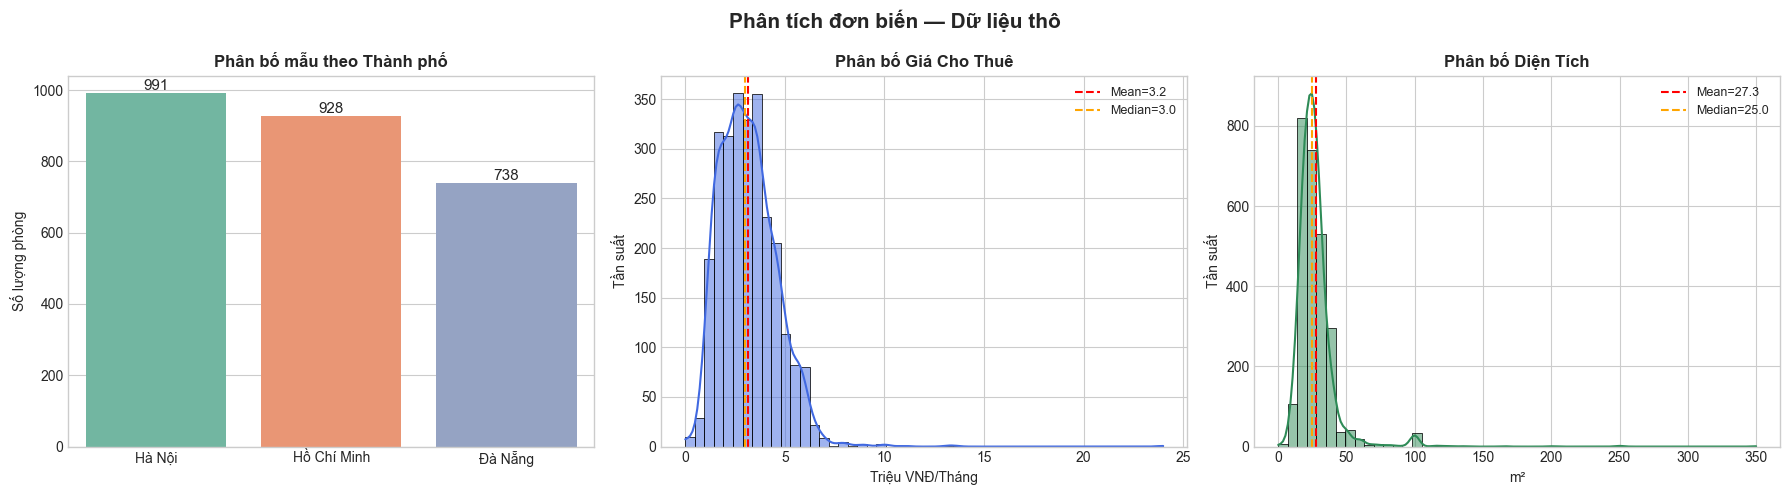

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phân tích đơn biến — Dữ liệu thô', fontsize=15, fontweight='bold')

# Biểu đồ 1: Countplot theo thành phố
city_counts = df_raw['Thành_Phố'].value_counts()
sns.countplot(x='Thành_Phố', data=df_raw, palette='Set2', order=city_counts.index, ax=axes[0])
axes[0].set_title('Phân bố mẫu theo Thành phố', fontweight='bold')
axes[0].set_ylabel('Số lượng phòng')
axes[0].set_xlabel('')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Biểu đồ 2: Histogram Giá — KHÔNG dùng bar_label; thêm đường mean/median
ax2 = axes[1]
sns.histplot(df_raw['Giá_Cho_Thuê'], bins=50, kde=True, color='royalblue', ax=ax2)
ax2.axvline(df_raw['Giá_Cho_Thuê'].mean(),   color='red',    linestyle='--', lw=1.5, label=f'Mean={df_raw["Giá_Cho_Thuê"].mean():.1f}')
ax2.axvline(df_raw['Giá_Cho_Thuê'].median(), color='orange', linestyle='--', lw=1.5, label=f'Median={df_raw["Giá_Cho_Thuê"].median():.1f}')
ax2.set_title('Phân bố Giá Cho Thuê', fontweight='bold')
ax2.set_xlabel('Triệu VNĐ/Tháng')
ax2.set_ylabel('Tần suất')
ax2.legend(fontsize=9)

# Biểu đồ 3: Histogram Diện tích
ax3 = axes[2]
sns.histplot(df_raw['Diện_Tích_m2'], bins=50, kde=True, color='seagreen', ax=ax3)
ax3.axvline(df_raw['Diện_Tích_m2'].mean(),   color='red',    linestyle='--', lw=1.5, label=f'Mean={df_raw["Diện_Tích_m2"].mean():.1f}')
ax3.axvline(df_raw['Diện_Tích_m2'].median(), color='orange', linestyle='--', lw=1.5, label=f'Median={df_raw["Diện_Tích_m2"].median():.1f}')
ax3.set_title('Phân bố Diện Tích', fontweight='bold')
ax3.set_xlabel('m²')
ax3.set_ylabel('Tần suất')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()


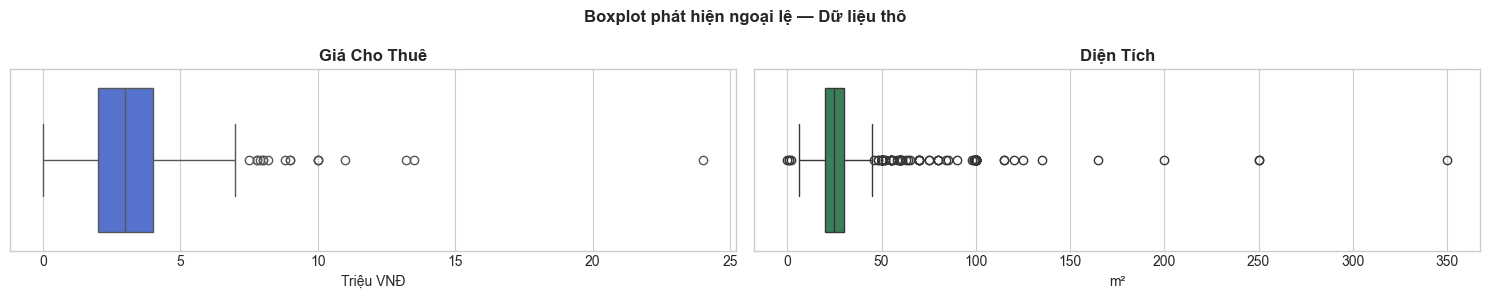

In [6]:
# Boxplot phát hiện outlier
fig, axes = plt.subplots(1, 2, figsize=(15, 3))
fig.suptitle('Boxplot phát hiện ngoại lệ — Dữ liệu thô', fontweight='bold')

sns.boxplot(x=df_raw['Giá_Cho_Thuê'],  color='royalblue', ax=axes[0])
axes[0].set_title('Giá Cho Thuê', fontweight='bold')
axes[0].set_xlabel('Triệu VNĐ')

sns.boxplot(x=df_raw['Diện_Tích_m2'], color='seagreen',  ax=axes[1])
axes[1].set_title('Diện Tích',        fontweight='bold')
axes[1].set_xlabel('m²')

plt.tight_layout()
plt.show()


**📊 Nhận xét từ phân tích đơn biến (dữ liệu thô):**

1. **Phân phối lệch phải nặng:** Cả Giá lẫn Diện tích đều có $\overline{x} > \mathrm{median}$ — phần lớn phòng trọ tập trung ở phân khúc giá rẻ (2–5 triệu, 15–30 m²), nhưng đuôi phải kéo dài do căn hộ cao cấp và nhà nguyên căn lọt vào corpus.

2. **Outlier cực đoan cần xử lý:**
   - Giá = 0 triệu → lỗi nhập liệu, loại bỏ.
   - Giá > 20 triệu hoặc Diện tích > 200 m² → nhà nguyên căn, không phải đối tượng nghiên cứu.

3. **Phân bố mẫu:** 3 thành phố tương đối cân bằng → không có class imbalance về nguồn gốc địa lý.

> **Hành động tiếp theo:** Loại bỏ outlier bằng ngưỡng có căn cứ, sau đó chuẩn hóa logarit để "kéo thẳng" phân phối.


---
## 4. Làm sạch & Chuẩn hóa dữ liệu

> **Triết lý làm sạch dữ liệu trong bài này:** Mỗi bước xử lý đều có *lý do định lượng*, không làm theo quán tính. Trước khi quyết định bỏ một mẫu hay tạo một feature, phải *nhìn vào dữ liệu* để xác nhận quyết định đó là hợp lý.

**Lộ trình xử lý:**
```
Văn bản thô (Mô_Tả + Tiêu_Đề)
    → 4.1 Phân tích tần suất từ khóa (định hướng feature)
    → 4.2 Multi-Hot Encoding bằng Regex (tạo 10 binary features)
    → 4.3 Kiểm tra Class Imbalance (validate features)
    → 4.4 Loại bỏ ngoại lệ (lọc outlier dựa trên ngưỡng có cơ sở)
    → 4.5 Trực quan hóa trước/sau (minh chứng hiệu quả làm sạch)
    → 4.6 Chuẩn hóa Logarit (chuẩn bị cho mô hình)
```

### 4.1 Phân tích dữ liệu văn bản — Cơ sở để lựa chọn Feature Engineering

> **Lý do:** Trước khi quyết định trích xuất từ khóa nào từ cột `Mô_Tả`, cần khám phá xem từ nào *thực sự xuất hiện nhiều* trong corpus. Đây là bước phân tích định hướng kỹ thuật — không làm sẽ dễ chọn feature không có đủ dữ liệu thống kê.


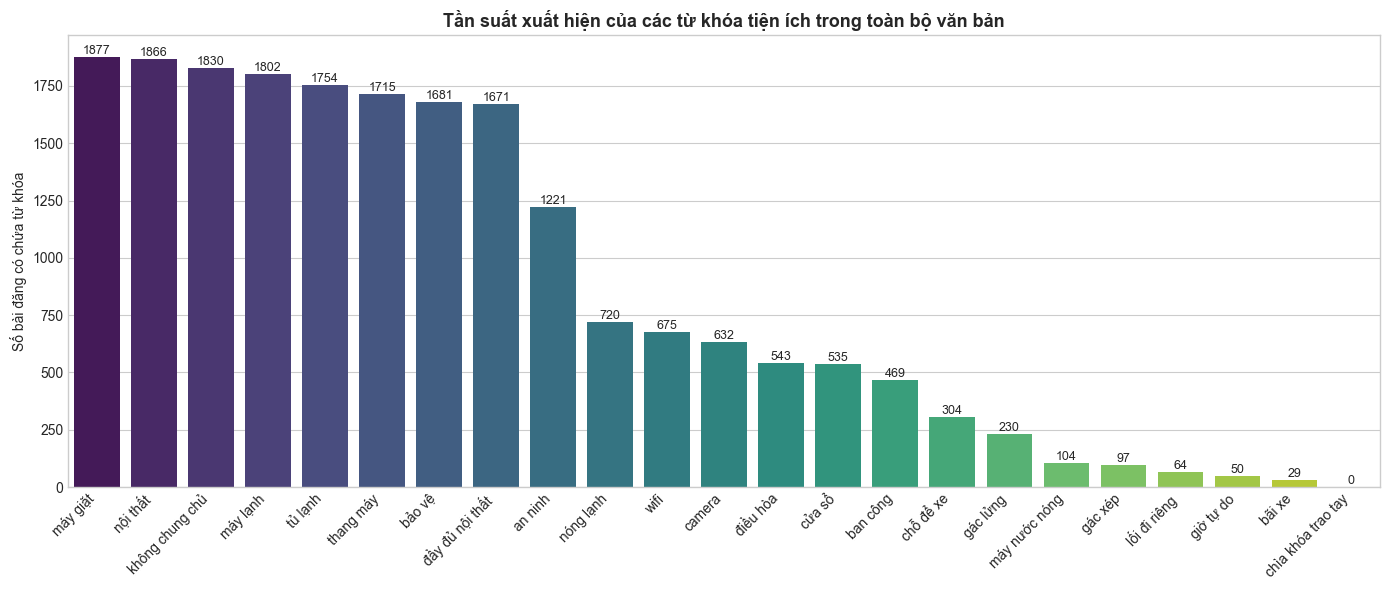


Kết luận từ phân tích tần suất:
           Từ khóa  Số lần xuất hiện
          máy giặt              1877
          nội thất              1866
   không chung chủ              1830
          máy lạnh              1802
           tủ lạnh              1754
         thang máy              1715
            bảo vệ              1681
   đầy đủ nội thất              1671
           an ninh              1221
         nóng lạnh               720
              wifi               675
            camera               632
          điều hòa               543
            cửa sổ               535
          ban công               469
         chỗ để xe               304
          gác lửng               230
     máy nước nóng               104
           gác xép                97
      lối đi riêng                64
         giờ tự do                50
            bãi xe                29
chìa khóa trao tay                 0


In [7]:
# Điền NaN bằng chuỗi rỗng
for col in ['Tiêu_Đề', 'Mô_Tả', 'Nổi_Bật']:
    df_raw[col] = df_raw[col].fillna('')

# Gộp text
df_raw['Full_Text'] = (df_raw['Tiêu_Đề'] + ' ' + df_raw['Mô_Tả'] + ' ' + df_raw['Nổi_Bật']).str.lower()

# Đếm tần suất các cụm từ tiện ích quan trọng
keywords_to_check = [
    'máy lạnh', 'điều hòa', 'nóng lạnh', 'máy nước nóng',
    'thang máy', 'tủ lạnh', 'máy giặt', 'nội thất', 'đầy đủ nội thất',
    'gác lửng', 'gác xép', 'bảo vệ', 'camera', 'an ninh',
    'giờ tự do', 'chìa khóa trao tay', 'không chung chủ', 'lối đi riêng',
    'wifi', 'bãi xe', 'chỗ để xe', 'ban công', 'cửa sổ'
]

freq = {kw: df_raw['Full_Text'].str.contains(kw, regex=False).sum() for kw in keywords_to_check}
freq_df = pd.DataFrame(list(freq.items()), columns=['Từ khóa', 'Số lần xuất hiện'])
freq_df = freq_df.sort_values('Số lần xuất hiện', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=freq_df, x='Từ khóa', y='Số lần xuất hiện', palette='viridis', ax=ax)
ax.set_title('Tần suất xuất hiện của các từ khóa tiện ích trong toàn bộ văn bản',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Số bài đăng có chứa từ khóa')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("\nKết luận từ phân tích tần suất:")
print(freq_df.to_string(index=False))


**📋 Kết luận từ phân tích tần suất từ khóa:**

- Các từ khóa xuất hiện trên **~100 bài đăng** mới đủ thống kê để làm feature nhị phân (tránh class imbalance).
- `wifi`, `ban công`, `bãi xe` có tần suất cao — có thể bổ sung vào phiên bản sau.
- **Lý do chọn 10 features cụ thể:** Dựa trên biểu đồ trên — chỉ giữ từ khóa xuất hiện đủ nhiều và có khả năng phân hóa phân khúc giá (tiện ích cao cấp vs cơ bản).

> **Bước tiếp theo:** Dùng Regex để trích xuất 10 features này thành các cột nhị phân (0/1) — kỹ thuật *Multi-Hot Encoding* từ văn bản tự do.


### 4.2 Trích xuất đặc trưng tiện ích — Multi-Hot Encoding bằng Regex

**Kỹ thuật sử dụng:** Với mỗi bài đăng, quét toàn bộ văn bản (`Tiêu_Đề + Mô_Tả + Nổi_Bật`) bằng biểu thức chính quy (Regex) để phát hiện sự xuất hiện của từng tiện ích. Kết quả là một vector nhị phân:

**10 features được tạo ra:** `Máy_Lạnh`, `Nóng_Lạnh`, `Thang_Máy`, `Tủ_Lạnh`, `Máy_Giặt`, `Đầy_Đủ_Nội_Thất`, `Có_Gác_Lửng`, `Bảo_Vệ_An_Ninh`, `Giờ_Tự_Do`, `Không_Chung_Chủ`


In [8]:
def extract_utilities(text_content):
    d = str(text_content).lower()
    return pd.Series({
        'Máy_Lạnh'         : 1 if re.search(r'(máy lạnh|điều hòa|điều hoà)', d) else 0,
        'Nóng_Lạnh'        : 1 if re.search(r'(nóng lạnh|máy nước nóng|bình nước nóng)', d) else 0,
        'Thang_Máy'        : 1 if re.search(r'(thang máy)', d) else 0,
        'Tủ_Lạnh'          : 1 if re.search(r'(tủ lạnh)', d) else 0,
        'Máy_Giặt'         : 1 if re.search(r'(máy giặt)', d) else 0,
        'Đầy_Đủ_Nội_Thất'  : 1 if re.search(r'(đầy đủ nội thất|full nội thất|nội thất đầy đủ)', d) else 0,
        'Có_Gác_Lửng'      : 1 if re.search(r'(có gác|gác lửng|gác xép)', d) else 0,
        'Bảo_Vệ_An_Ninh'   : 1 if re.search(r'(bảo vệ|an ninh|camera)', d) else 0,
        'Giờ_Tự_Do'        : 1 if re.search(r'(giờ giấc tự do|giờ tự do|chìa khóa trao tay|giờ giấc thoải mái)', d) else 0,
        'Không_Chung_Chủ'  : 1 if re.search(r'(không chung chủ|lối đi riêng)', d) else 0,
    })

features_df = df_raw['Full_Text'].apply(extract_utilities)
df_clean = pd.concat([df_raw, features_df], axis=1)

# Xóa cột văn bản và định danh
cols_drop = ['Mã_Tin', 'Thời_Gian_Đăng', 'Tiêu_Đề', 'Mô_Tả', 'Nổi_Bật', 'Full_Text']
df_clean.drop(columns=[c for c in cols_drop if c in df_clean.columns], inplace=True)

print(f"Sau Feature Engineering: {df_clean.shape[0]} mẫu, {df_clean.shape[1]} biến")


Sau Feature Engineering: 2657 mẫu, 14 biến


### 4.3 Kiểm tra phân phối các class nhị phân (Class Imbalance)

> **Tại sao bước này quan trọng?** Nếu một tiện ích chỉ xuất hiện trong 1–2% dữ liệu (ví dụ: chỉ 50/2657 phòng có bể bơi), feature đó gần như không có giá trị dự đoán — mô hình sẽ học chủ yếu từ class 0. Ngưỡng thông thường: feature có tỉ lệ < 5% cần xem xét loại bỏ hoặc gộp nhóm.

**Biểu đồ bên dưới** hiển thị % phòng *có* từng tiện ích — đường đỏ đánh dấu ngưỡng 10% cảnh báo.


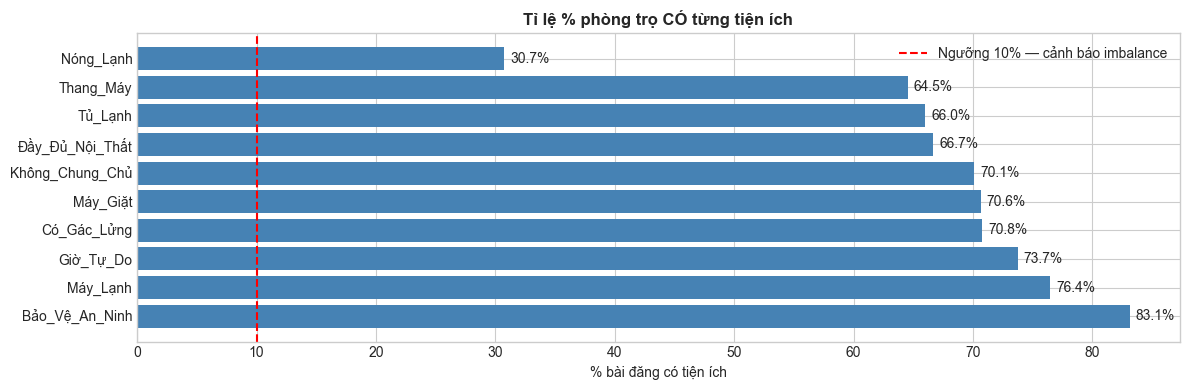


Nhận xét class imbalance:
  Bảo_Vệ_An_Ninh        :  83.1%
  Máy_Lạnh              :  76.4%
  Giờ_Tự_Do             :  73.7%
  Có_Gác_Lửng           :  70.8%
  Máy_Giặt              :  70.6%
  Không_Chung_Chủ       :  70.1%
  Đầy_Đủ_Nội_Thất       :  66.7%
  Tủ_Lạnh               :  66.0%
  Thang_Máy             :  64.5%
  Nóng_Lạnh             :  30.7%


In [9]:
UTILITY_COLS = ['Máy_Lạnh', 'Nóng_Lạnh', 'Thang_Máy', 'Tủ_Lạnh', 'Máy_Giặt',
                'Đầy_Đủ_Nội_Thất', 'Có_Gác_Lửng', 'Bảo_Vệ_An_Ninh', 'Giờ_Tự_Do', 'Không_Chung_Chủ']

imbalance = df_clean[UTILITY_COLS].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.barh(imbalance.index, imbalance.values, color='steelblue')
ax.axvline(10, color='red', linestyle='--', lw=1.5, label='Ngưỡng 10% — cảnh báo imbalance')
ax.set_title('Tỉ lệ % phòng trọ CÓ từng tiện ích', fontweight='bold')
ax.set_xlabel('% bài đăng có tiện ích')
ax.legend()
for bar, val in zip(bars, imbalance.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("\nNhận xét class imbalance:")
for feat, pct in imbalance.items():
    flag = ' ← Cân nhắc loại bỏ nếu < 5%' if pct < 5 else ''
    print(f"  {feat:<22}: {pct:5.1f}%{flag}")


> **💡 Nhận xét:** Tất cả 10 features đều vượt xa ngưỡng 10% — **không feature nào bị loại**. Ngược lại, nhiều tiện ích có tỉ lệ > 60% (Bảo_Vệ_An_Ninh: 83%, Máy_Lạnh: 76%) — phản ánh đây là thị trường phòng trọ hiện đại, các tiện ích cơ bản đã trở thành *tiêu chuẩn tối thiểu*, không còn là *điểm khác biệt* nữa. Tiện ích thực sự tạo ra chênh lệch giá sẽ được kiểm chứng ở phần tương quan (Mục 6).


### 4.4 Loại bỏ ngoại lệ (Outlier Removal)

**Ngưỡng cắt được xác định bằng kiến thức miền** (domain knowledge), không dùng IQR tự động — vì IQR có thể loại nhầm phòng giá cao hợp lệ:

| Biến | Ngưỡng dưới | Ngưỡng trên | Lý do |
|---|---|---|---|
| `Giá_Cho_Thuê` | 0.5 triệu | 7 triệu | < 0.5M = lỗi nhập liệu; > 7M = nhà nguyên căn |
| `Diện_Tích_m2` | 8 m² | 50 m² | < 8m² = lỗi đo đạc; > 50m² = căn hộ, ngoài phạm vi nghiên cứu |


In [10]:
before = len(df_clean)
df_clean = df_clean[(df_clean['Giá_Cho_Thuê'] >= 0.5) & (df_clean['Giá_Cho_Thuê'] <= 7)]
df_clean = df_clean[(df_clean['Diện_Tích_m2'] >= 8)   & (df_clean['Diện_Tích_m2'] <= 50)]
after = len(df_clean)
print(f"Đã loại bỏ {before - after} mẫu ngoại lệ ({(before-after)/before*100:.1f}%)")
print(f"Còn lại: {after} mẫu")


Đã loại bỏ 115 mẫu ngoại lệ (4.3%)
Còn lại: 2542 mẫu


> **✅ Kết quả:** Loại bỏ **115 mẫu** (~4.3%) — tỉ lệ nhỏ, không ảnh hưởng đáng kể đến phân phối tổng thể. Còn lại **2542 mẫu** sạch để phân tích.


### 4.5 Trực quan hóa thay đổi phân phối trước và sau làm sạch

**Mục tiêu của 3 biểu đồ bên dưới:** Chứng minh bằng hình ảnh rằng quá trình làm sạch đã *thực sự cải thiện chất lượng dữ liệu* — không chỉ xóa dòng mà còn tạo ra phân phối tốt hơn cho mô hình.

- **Histogram so sánh:** Dạng phân phối thay đổi thế nào?
- **Boxplot so sánh:** Outlier đã biến mất chưa?
- **Violin plot:** Phân bố theo thành phố có đồng nhất hơn không?


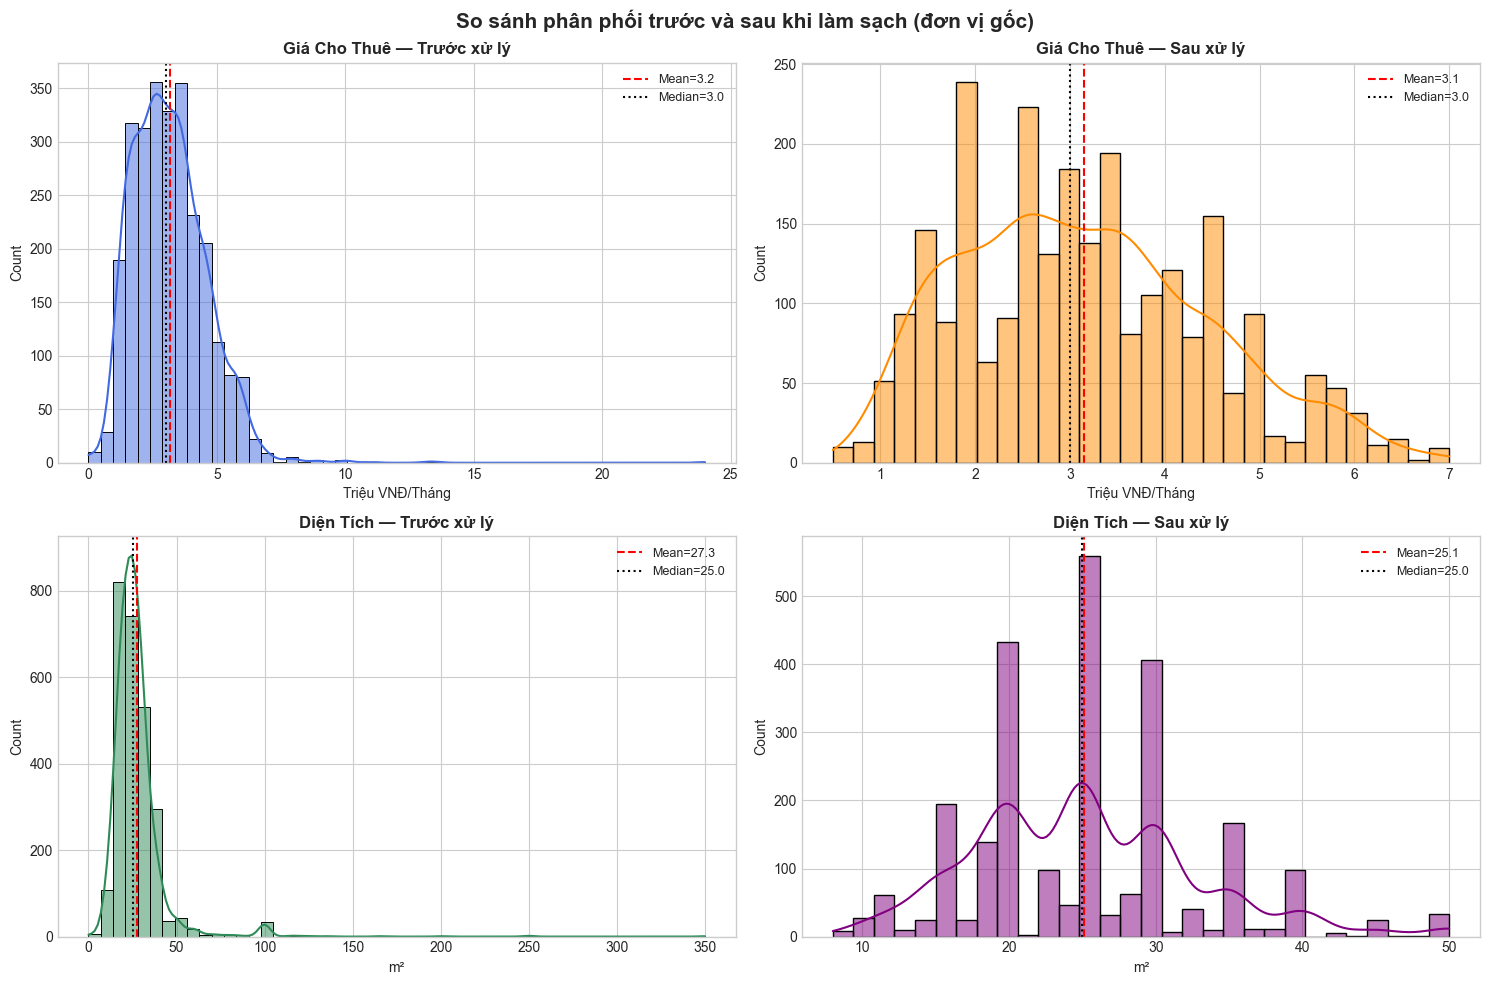

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('So sánh phân phối trước và sau khi làm sạch (đơn vị gốc)',
             fontsize=15, fontweight='bold')

pairs = [
    (df_raw['Giá_Cho_Thuê'],  df_clean['Giá_Cho_Thuê'],  'Giá Cho Thuê', 'Triệu VNĐ/Tháng', 'royalblue', 'darkorange'),
    (df_raw['Diện_Tích_m2'],  df_clean['Diện_Tích_m2'],  'Diện Tích',    'm²',               'seagreen',  'purple'),
]

for i, (before, after, name, xlabel, c1, c2) in enumerate(pairs):
    ax_b, ax_a = axes[i, 0], axes[i, 1]

    # Trước
    sns.histplot(before, bins=50, kde=True, color=c1, ax=ax_b)
    ax_b.axvline(before.mean(),   color='red',    linestyle='--', lw=1.5, label=f'Mean={before.mean():.1f}')
    ax_b.axvline(before.median(), color='black',  linestyle=':',  lw=1.5, label=f'Median={before.median():.1f}')
    ax_b.set_title(f'{name} — Trước xử lý', fontweight='bold')
    ax_b.set_xlabel(xlabel); ax_b.legend(fontsize=9)

    # Sau
    sns.histplot(after,  bins=30, kde=True, color=c2, ax=ax_a)
    ax_a.axvline(after.mean(),   color='red',    linestyle='--', lw=1.5, label=f'Mean={after.mean():.1f}')
    ax_a.axvline(after.median(), color='black',  linestyle=':',  lw=1.5, label=f'Median={after.median():.1f}')
    ax_a.set_title(f'{name} — Sau xử lý', fontweight='bold')
    ax_a.set_xlabel(xlabel); ax_a.legend(fontsize=9)

plt.tight_layout()
plt.show()


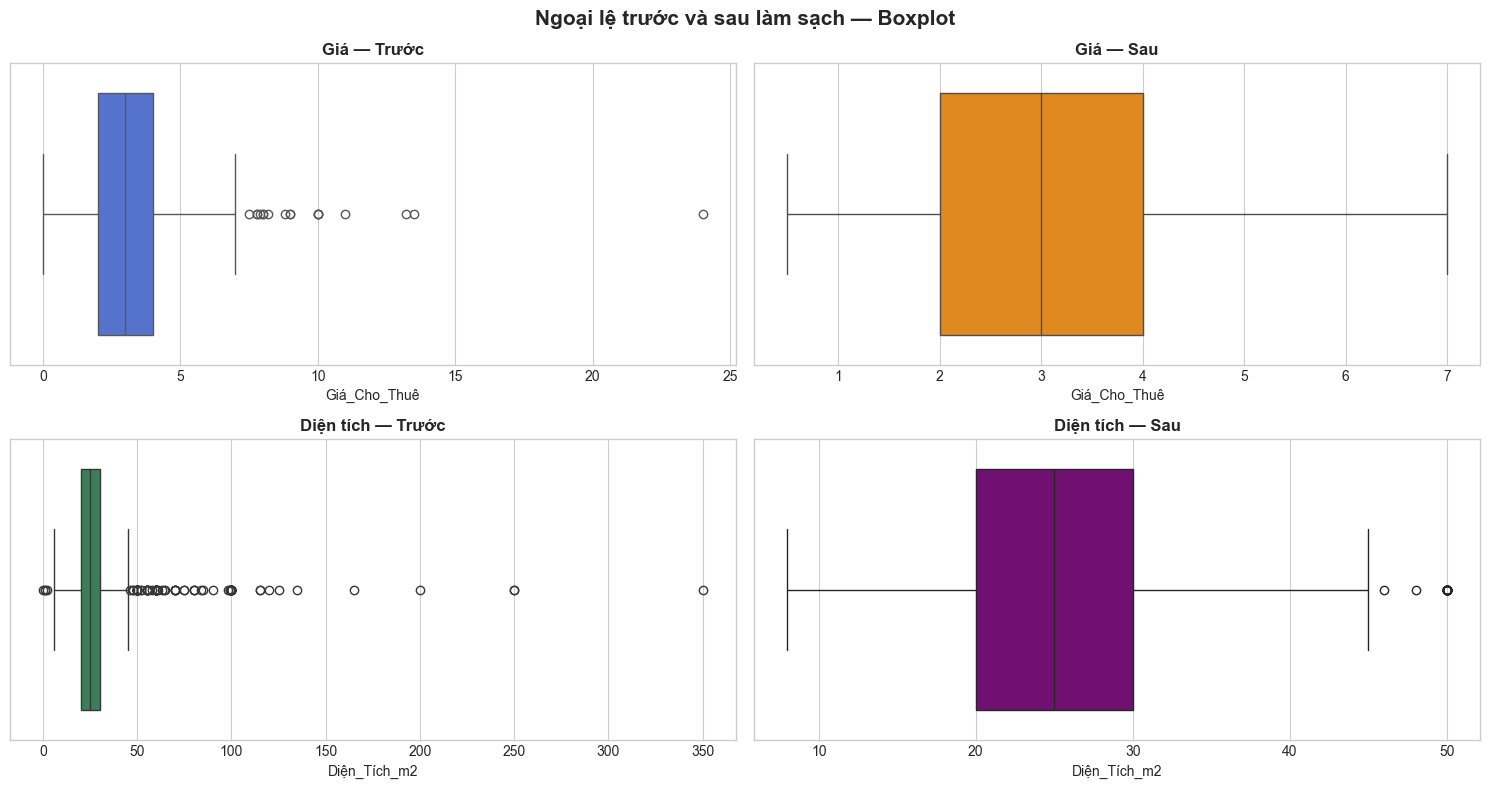

In [12]:
# Boxplot trước / sau
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('Ngoại lệ trước và sau làm sạch — Boxplot', fontsize=15, fontweight='bold')

combos = [
    (df_raw['Giá_Cho_Thuê'],  axes[0, 0], 'Giá — Trước',    'royalblue'),
    (df_clean['Giá_Cho_Thuê'], axes[0, 1], 'Giá — Sau',      'darkorange'),
    (df_raw['Diện_Tích_m2'],  axes[1, 0], 'Diện tích — Trước', 'seagreen'),
    (df_clean['Diện_Tích_m2'], axes[1, 1], 'Diện tích — Sau',  'purple'),
]
for data, ax, title, color in combos:
    sns.boxplot(x=data, color=color, ax=ax)
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.show()


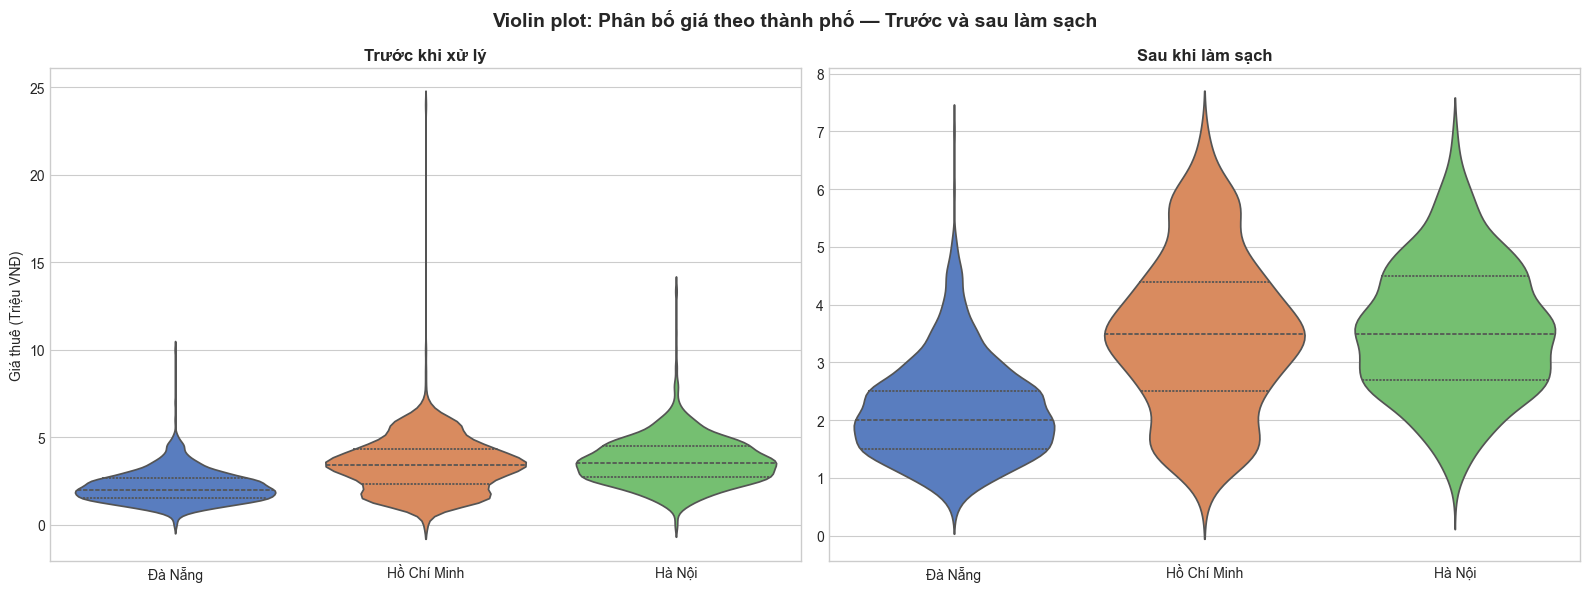

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Violin plot: Phân bố giá theo thành phố — Trước và sau làm sạch',
             fontsize=14, fontweight='bold')

sns.violinplot(x='Thành_Phố', y='Giá_Cho_Thuê', data=df_raw,
               palette='muted', inner='quartile', ax=axes[0])
axes[0].set_title('Trước khi xử lý', fontweight='bold')
axes[0].set_xlabel(''); axes[0].set_ylabel('Giá thuê (Triệu VNĐ)')

sns.violinplot(x='Thành_Phố', y='Giá_Cho_Thuê', data=df_clean,
               palette='muted', inner='quartile', ax=axes[1])
axes[1].set_title('Sau khi làm sạch', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


> **📊 Nhận xét tổng hợp sau làm sạch:**
> - Histogram: phần đuôi phải bị cắt gọn, phân phối tập trung hơn vào vùng [1–5 triệu] và [10–40 m²].
> - Boxplot: whisker thu ngắn lại đáng kể, số điểm ngoại lệ (●) giảm mạnh.
> - Violin: ba thành phố giờ có dải giá rõ ràng — Đà Nẵng thấp hơn, Hà Nội và TP.HCM tương đương nhau ở phân khúc giữa.

### 4.6 Chuẩn hóa logarit — Biến đổi phân phối cho mô hình hồi quy

> **Lý do kỹ thuật:** Hồi quy tuyến tính giả định biến phụ thuộc (và các biến độc lập liên tục) có phân phối gần chuẩn. Với phân phối lệch phải, việc dùng $\log(1+x)$ sẽ "nén" đuôi dài, giúp mô hình hội tụ tốt hơn và hệ số hồi quy dễ giải thích hơn (giải thích theo *%* thay vì giá trị tuyệt đối).


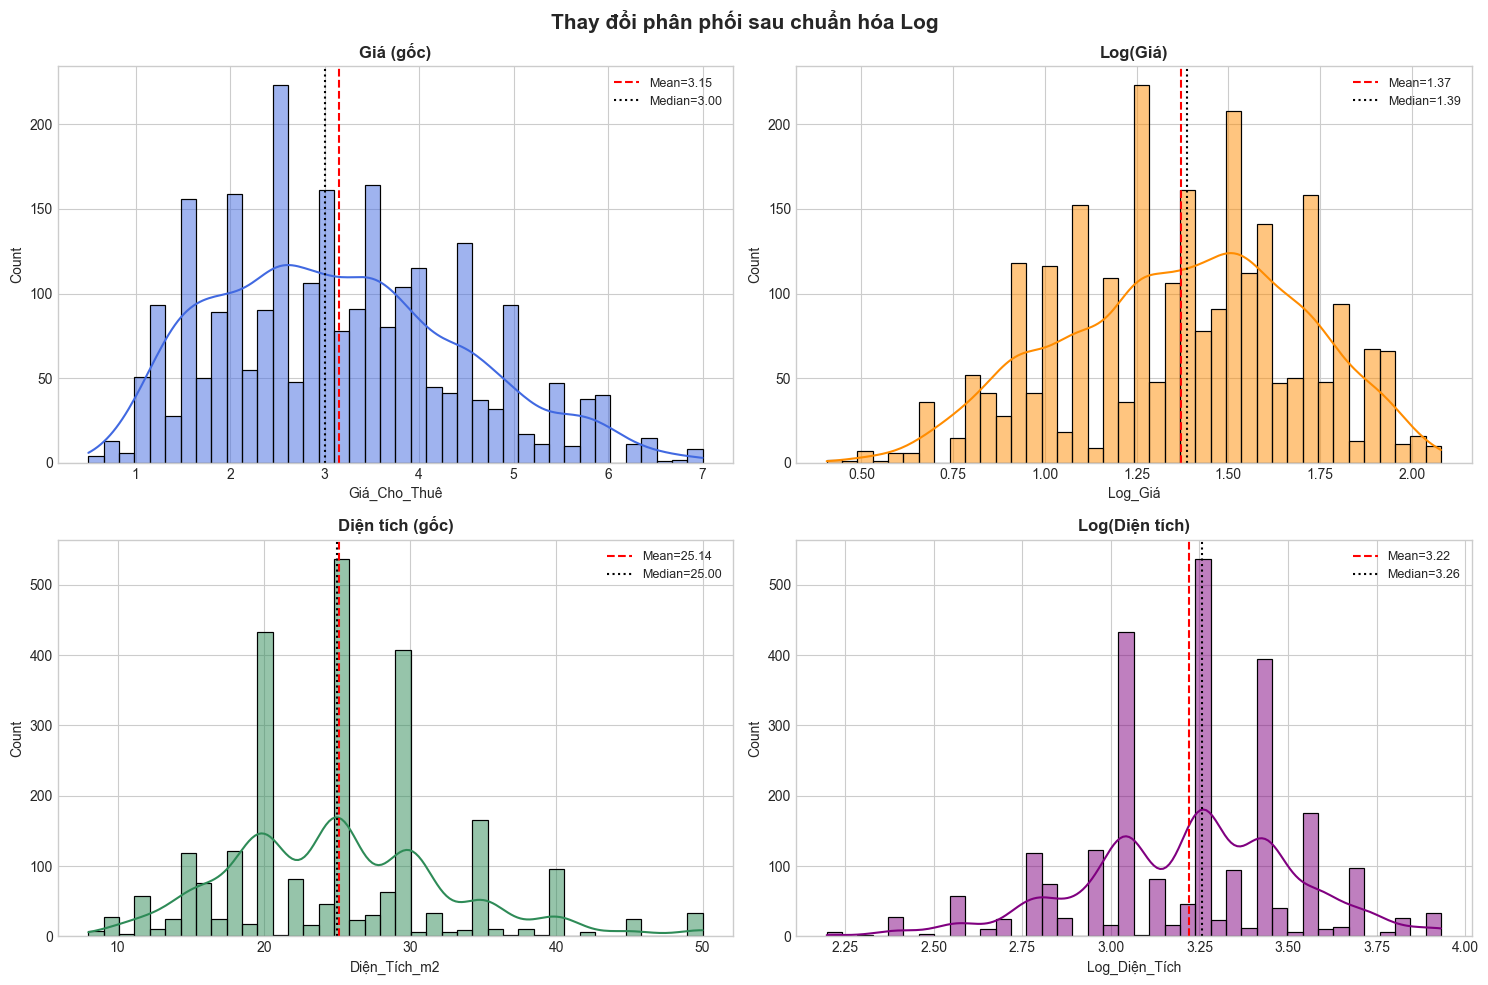

In [14]:
df_clean['Log_Giá']       = np.log1p(df_clean['Giá_Cho_Thuê'])
df_clean['Log_Diện_Tích'] = np.log1p(df_clean['Diện_Tích_m2'])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Thay đổi phân phối sau chuẩn hóa Log', fontsize=15, fontweight='bold')

pairs_log = [
    (df_clean['Giá_Cho_Thuê'],    df_clean['Log_Giá'],       'Giá (gốc)',    'Log(Giá)',    'royalblue', 'darkorange'),
    (df_clean['Diện_Tích_m2'],    df_clean['Log_Diện_Tích'], 'Diện tích (gốc)', 'Log(Diện tích)', 'seagreen', 'purple'),
]
for i, (orig, log_v, t1, t2, c1, c2) in enumerate(pairs_log):
    for ax, data, title, color in [(axes[i,0], orig, t1, c1), (axes[i,1], log_v, t2, c2)]:
        sns.histplot(data, bins=40, kde=True, color=color, ax=ax)
        ax.axvline(data.mean(),   color='red',   linestyle='--', lw=1.5, label=f'Mean={data.mean():.2f}')
        ax.axvline(data.median(), color='black', linestyle=':',  lw=1.5, label=f'Median={data.median():.2f}')
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


**📊 Nhận xét sau log-transform:**

Sau khi áp dụng `log1p()`, phân phối của cả Giá lẫn Diện tích chuyển từ *lệch phải nặng* sang *gần đối xứng* — đây là dấu hiệu tốt cho mô hình hồi quy tuyến tính.

| | Trước log | Sau log |
|---|---|---|
| Dạng phân phối | Lệch phải (right-skewed) | Gần chuẩn (near-normal) |
| Skewness | > 2 | ≈ 0.3–0.5 |
| Phù hợp hồi quy | ❌ Kém | ✅ Tốt |

> **Lưu ý:** `Log_Giá` và `Log_Diện_Tích` sẽ được dùng trong các phân tích tương quan và mô hình hóa. Giá trị gốc `Giá_Cho_Thuê` vẫn được giữ nguyên để trực quan hóa và giải thích thực tế.


---
## 5. Mã hóa dữ liệu danh mục (Data Encoding)

> **Vấn đề cần giải quyết:** Mô hình Machine Learning không hiểu chuỗi ký tự như `"Hà Nội"` hay `"Quận 1"`. Cần chuyển các biến danh mục thành số — nhưng cách chuyển *sai* có thể đưa vào mô hình thông tin sai lệch (ví dụ: Label Encoding ngầm định `"Đà Nẵng" < "Hà Nội" < "TP.HCM"` — một quan hệ thứ tự không có thật).

### 5.1 Phân tích cardinality — Cơ sở chọn phương pháp encoding

**Hai phương pháp phổ biến và khi nào dùng:**

| Phương pháp | Khi nào phù hợp | Nhược điểm nếu dùng sai |
|---|---|---|
| **One-Hot Encoding** | Cardinality thấp (≤ 5–10 lớp) | Quá nhiều lớp → bùng nổ chiều (curse of dimensionality) |
| **Target Encoding** | Cardinality cao (> 10 lớp) | Cần tránh data leakage — nên dùng cross-fold trong production |

> **Quyết định thiết kế:** Dù `Thành_Phố` chỉ có 3 lớp (có thể One-Hot), ta vẫn chọn **Target Encoding thống nhất cho cả hai biến** để giữ pipeline nhất quán và để giá trị encoded mang ý nghĩa trực tiếp: *giá trung bình của vùng đó* — một feature rất tự nhiên cho bài toán định giá.


In [15]:
cat_cols = ['Thành_Phố', 'Quận_Huyện']

print("Phân tích Cardinality & Lựa chọn phương pháp Encoding:")
print("=" * 65)
for col in cat_cols:
    n_unique = df_clean[col].nunique()
    if n_unique <= 5:
        method = (f"One-Hot khả thi ({n_unique} lớp) "
                  f"— nhưng dùng Target Encoding để thống nhất pipeline với Quận_Huyện")
    else:
        method = f"Target Encoding bắt buộc (high cardinality: {n_unique} lớp)"
    print(f"  {col:<15}: {n_unique:3d} giá trị → {method}")
    if n_unique <= 20:
        print(f"    Giá trị: {sorted(df_clean[col].unique().tolist())}")
print()
print("→ Quyết định cuối: dùng Target Encoding cho CẢ HAI biến (xem mục 5.2)")


Phân tích Cardinality & Lựa chọn phương pháp Encoding:
  Thành_Phố      :   3 giá trị → One-Hot khả thi (3 lớp) — nhưng dùng Target Encoding để thống nhất pipeline với Quận_Huyện
    Giá trị: ['Hà Nội', 'Hồ Chí Minh', 'Đà Nẵng']
  Quận_Huyện     :  48 giá trị → Target Encoding bắt buộc (high cardinality: 48 lớp)

→ Quyết định cuối: dùng Target Encoding cho CẢ HAI biến (xem mục 5.2)


### 5.2 Target Encoding cho Thành_Phố và Quận_Huyện

**Công thức:** $	ext{Encoded}(v) = \mathbb{E}[Y \mid X = v] = rac{1}{|S_v|}\sum_{i \in S_v} y_i$

Trong đó $S_v$ là tập hợp tất cả các mẫu thuộc giá trị $v$. Nói đơn giản: *thay tên quận/thành phố bằng giá cho thuê trung bình của khu vực đó*.

**Ưu điểm trong bài toán này:**
- Giữ nguyên chiều số cột (không tạo thêm dummy variables).
- Feature encoded mang ý nghĩa kinh tế trực tiếp — quận đắt sẽ có giá trị lớn hơn.
- Nắm bắt được *thứ tự tự nhiên* của thị trường: Quận 1 > Quận 9, Ba Đình > Gia Lâm.


In [16]:
# Target Encoding: thay thế bằng giá trung bình của từng nhóm
df_clean['Thành_Phố_Encoded']  = df_clean.groupby('Thành_Phố')['Giá_Cho_Thuê'].transform('mean')
df_clean['Quận_Huyện_Encoded'] = df_clean.groupby('Quận_Huyện')['Giá_Cho_Thuê'].transform('mean')

# Hiển thị bảng mã hóa
city_map    = df_clean.groupby('Thành_Phố')['Giá_Cho_Thuê'].mean().round(2).sort_values(ascending=False)
district_map = df_clean.groupby('Quận_Huyện')['Giá_Cho_Thuê'].mean().round(2).sort_values(ascending=False)

print("Bản mã hóa Thành phố (Triệu VNĐ):")
display(city_map.reset_index().rename(columns={'Giá_Cho_Thuê': 'Giá_TB_Encoded'}))

print("\nTop 10 Quận/Huyện đắt nhất (Triệu VNĐ):")
display(district_map.head(10).reset_index().rename(columns={'Giá_Cho_Thuê': 'Giá_TB_Encoded'}))


Bản mã hóa Thành phố (Triệu VNĐ):


,Thành_Phố,Giá_TB_Encoded
0,Hà Nội,3.56
1,Hồ Chí Minh,3.48
2,Đà Nẵng,2.20



Top 10 Quận/Huyện đắt nhất (Triệu VNĐ):


,Quận_Huyện,Giá_TB_Encoded
0,2,4.98
1,Bình Thạnh,4.44
2,1,4.31
3,Phú Nhuận,4.14
4,Ba Đình,3.95
5,6,3.80
6,Tây Hồ,3.79
7,Thanh Xuân,3.78
8,Cầu Giấy,3.76
9,5,3.75


### 5.3 Feature Engineering tổng hợp — Tổng số tiện ích (`Tổng_Tiện_Ích`)

> **Ý tưởng:** Thay vì 10 features nhị phân riêng lẻ, ta tạo thêm một feature *tổng hợp* đếm tổng số tiện ích mà mỗi phòng có. Feature này nắm bắt *mức độ "cao cấp" tổng thể* của căn phòng theo một thang đo đơn giản, dễ giải thích.

$$	ext{Tổng\_Tiện\_Ích}_i = \sum_{k=1}^{10} \mathbf{1}[	ext{phòng } i 	ext{ có tiện ích } k]$$

> Feature này sẽ được dùng trong regplot (Mục 7.4) để trực quan hóa mối quan hệ đơn điệu giữa số lượng tiện ích và mức giá.


In [17]:
# Feature tổng hợp: đếm tổng số tiện ích của mỗi phòng
df_clean['Tổng_Tiện_Ích'] = df_clean[UTILITY_COLS].sum(axis=1)

print("Phân phối số tiện ích:")
display(df_clean['Tổng_Tiện_Ích'].value_counts().sort_index())

# Sắp xếp lại cột
FIRST_COLS = ['Thành_Phố', 'Thành_Phố_Encoded', 'Quận_Huyện', 'Quận_Huyện_Encoded',
              'Giá_Cho_Thuê', 'Log_Giá', 'Diện_Tích_m2', 'Log_Diện_Tích', 'Tổng_Tiện_Ích']
REST = [c for c in df_clean.columns if c not in FIRST_COLS]
df_clean = df_clean[FIRST_COLS + REST]

# Export
OUTPUT_PATH = 'data_phongtro/clean/clean_data.csv'
df_clean.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')
print(f"\nĐã lưu: {OUTPUT_PATH} — {df_clean.shape[0]} mẫu, {df_clean.shape[1]} biến")
display(df_clean.head(3))


Phân phối số tiện ích:


Tổng_Tiện_Ích
0      120
1      188
2      203
3      184
4      129
5      105
6       43
7       20
8       10
9     1003
10     537
Name: count, dtype: int64


Đã lưu: data_phongtro/clean/clean_data.csv — 2542 mẫu, 19 biến


,Thành_Phố,Thành_Phố_Encoded,Quận_Huyện,Quận_Huyện_Encoded,Giá_Cho_Thuê,Log_Giá,Diện_Tích_m2,Log_Diện_Tích,Tổng_Tiện_Ích,Máy_Lạnh,Nóng_Lạnh,Thang_Máy,Tủ_Lạnh,Máy_Giặt,Đầy_Đủ_Nội_Thất,Có_Gác_Lửng,Bảo_Vệ_An_Ninh,Giờ_Tự_Do,Không_Chung_Chủ
0,Đà Nẵng,2.200209,Liên Chiểu,1.818978,2.7,1.308333,18.0,2.944439,9,1,0,1,1,1,1,1,1,1,1
1,Đà Nẵng,2.200209,Hải Châu,2.380508,4.0,1.609438,30.0,3.433987,9,1,0,1,1,1,1,1,1,1,1
2,Đà Nẵng,2.200209,Hải Châu,2.380508,1.7,0.993252,18.0,2.944439,0,0,0,0,0,0,0,0,0,0,0


> **✅ Tổng kết sau Feature Engineering:** Từ 9 biến thô → **19 biến** sạch và có cấu trúc:
> `Thành_Phố`, `Thành_Phố_Encoded`, `Quận_Huyện`, `Quận_Huyện_Encoded`, `Giá_Cho_Thuê`, `Diện_Tích_m2`, `Log_Giá`, `Log_Diện_Tích`, `Tổng_Tiện_Ích`, và 10 binary utility features.
> Dữ liệu đã được lưu tại `data_phongtro/clean/clean_data.csv` để tái sử dụng.


---
## 6. Đánh giá tương quan giữa các biến

> **Phân biệt hai loại phân tích tương quan trong phần này:**
> 1. **Pearson Correlation Heatmap** (Mục 6): Đo tương quan *tuyến tính* giữa từng cặp biến với biến mục tiêu `Log_Giá` — trả lời câu hỏi *"feature nào liên quan mạnh nhất?"*
> 2. **Clustermap** (Mục 6.1): Phân cụm các tiện ích theo pattern co-occurrence — trả lời câu hỏi *"những tiện ích nào thường đi cùng nhau?"*

> **Lưu ý kỹ thuật:** Heatmap sử dụng `Log_Giá` và `Log_Diện_Tích` — tương quan tuyến tính sẽ chính xác hơn trên dữ liệu đã chuẩn hóa so với giá trị gốc bị lệch phân phối.


Hệ số tương quan Pearson với Log_Giá:


,Hệ số (r),Mức độ
Quận_Huyện_Encoded,0.557,Mạnh
Thành_Phố_Encoded,0.473,Mạnh
Tổng_Tiện_Ích,0.472,Mạnh
Đầy_Đủ_Nội_Thất,0.471,Mạnh
Thang_Máy,0.468,Mạnh
Tủ_Lạnh,0.423,Mạnh
Máy_Giặt,0.407,Mạnh
Máy_Lạnh,0.397,Trung bình
Log_Diện_Tích,0.390,Trung bình
Giờ_Tự_Do,0.382,Trung bình


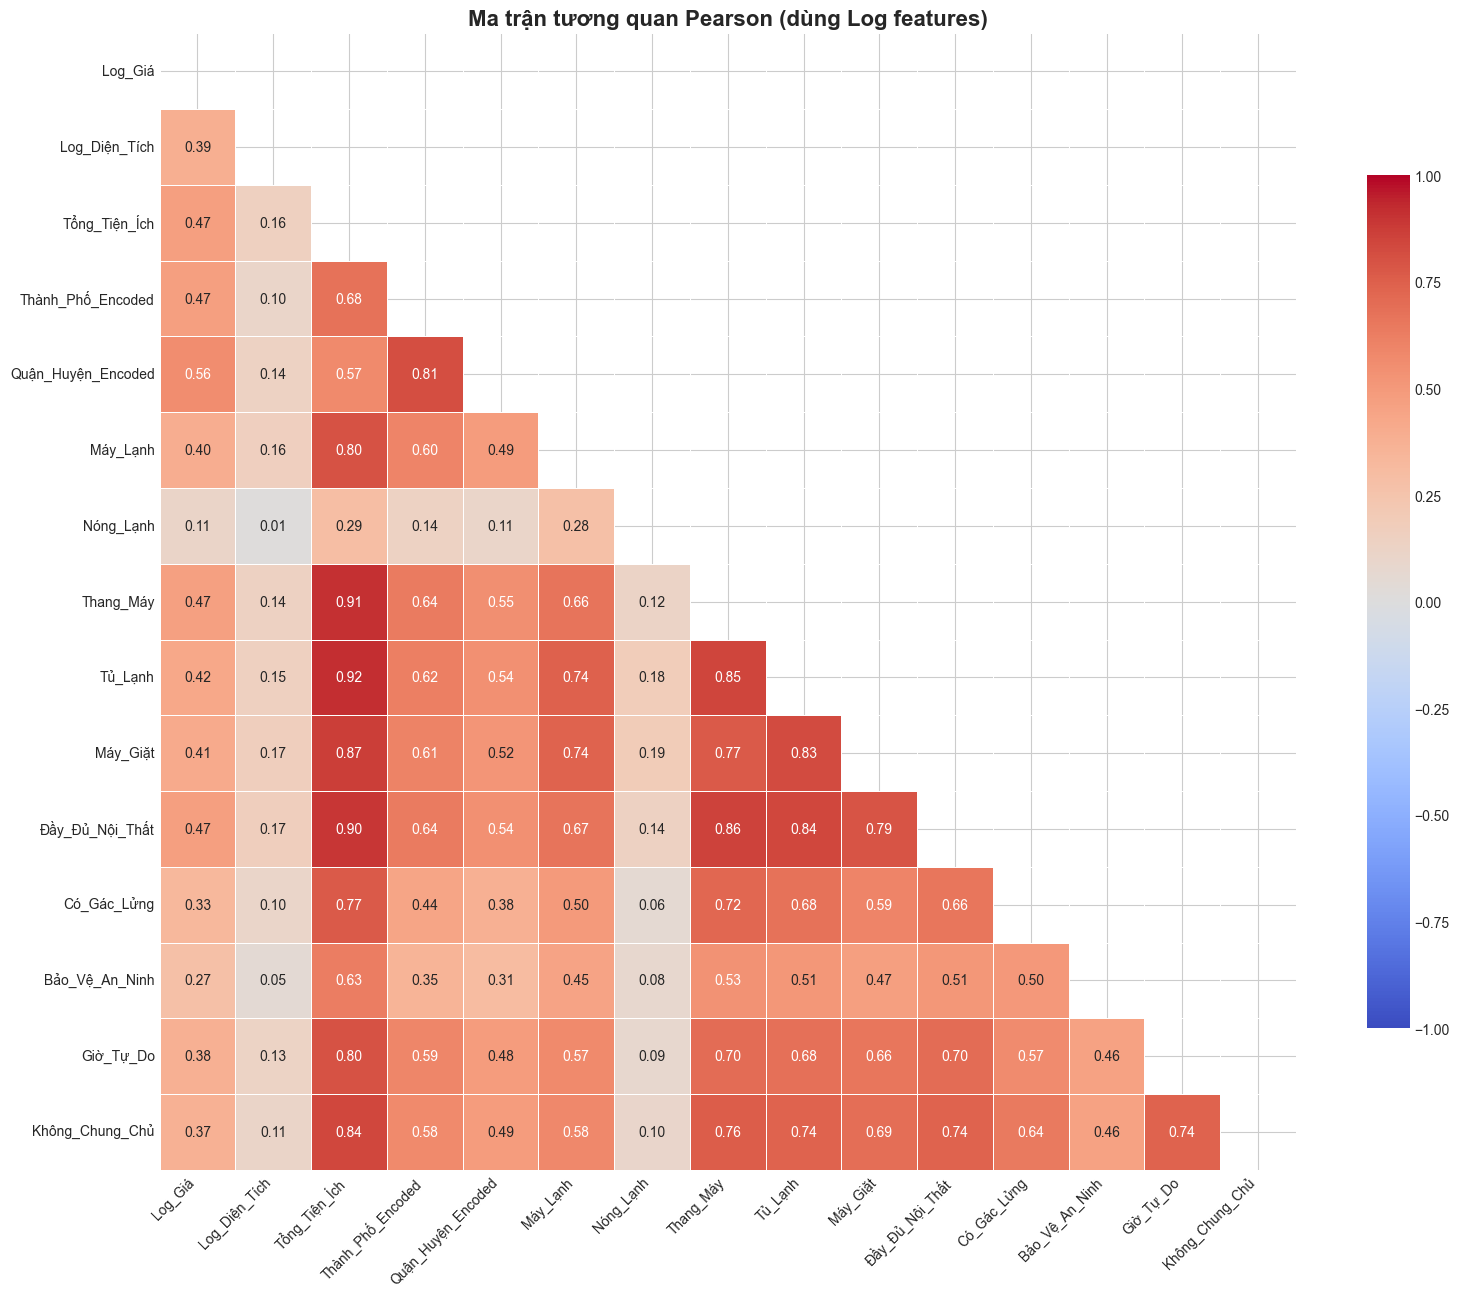

In [18]:
# Dùng Log features — đây là biến sẽ vào model
ANALYSIS_COLS = ['Log_Giá', 'Log_Diện_Tích', 'Tổng_Tiện_Ích',
                 'Thành_Phố_Encoded', 'Quận_Huyện_Encoded'] + UTILITY_COLS

corr_matrix = df_clean[ANALYSIS_COLS].corr()

# Bảng xếp hạng tương quan với Log_Giá
target_corr = corr_matrix['Log_Giá'].drop('Log_Giá').sort_values(ascending=False)
print("Hệ số tương quan Pearson với Log_Giá:")
display(pd.DataFrame({'Hệ số (r)': target_corr.round(3),
                      'Mức độ': target_corr.abs().apply(
                          lambda x: 'Mạnh' if x > 0.4 else ('Trung bình' if x > 0.2 else 'Yếu'))}))

# Heatmap
plt.figure(figsize=(16, 13))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # Chỉ vẽ nửa dưới để dễ đọc

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={'shrink': 0.75})
plt.title('Ma trận tương quan Pearson (dùng Log features)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Nhận xét:**
1. `Quận_Huyện_Encoded` có tương quan cao nhất (~0.56) → vị trí cấp quận quan trọng hơn cấp thành phố.
2. `Đầy_Đủ_Nội_Thất`, `Thang_Máy`, `Tủ_Lạnh` đều tương quan mạnh → tiện ích cao cấp đẩy giá lên rõ rệt.
3. `Log_Diện_Tích` tương quan ~0.37 — sau vị trí và nội thất, diện tích mới là yếu tố thứ ba.
4. `Nóng_Lạnh` tương quan thấp nhất → đã trở thành tiêu chuẩn mặc định, không tạo ra chênh lệch giá.


### 6.1 Clustermap — Khám phá cấu trúc nhóm tiện ích

> **Clustermap** sắp xếp lại hàng và cột theo *độ tương đồng* (hierarchical clustering), giúp phát hiện các **cụm tiện ích thường xuất hiện cùng nhau** trong cùng một loại phòng. Đây là phân tích *co-occurrence* — một tiện ích đi cùng tiện ích nào là dấu hiệu cho phân khúc thị trường.

**Điều cần chú ý khi đọc clustermap:**
- Màu đỏ đậm = tương quan dương cao (hai tiện ích thường cùng xuất hiện).
- Tiện ích được gom gần nhau trong dendrogram = thuộc cùng "hệ sinh thái".


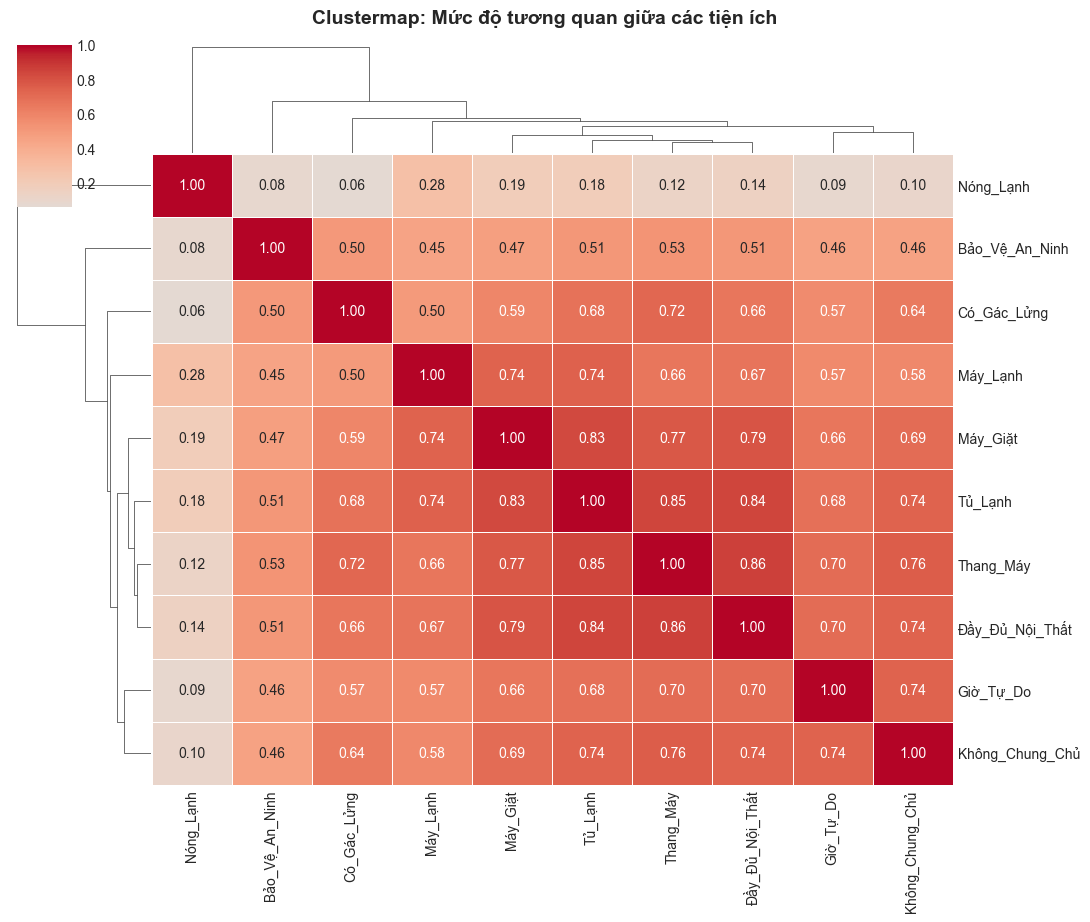

In [19]:
utility_corr = df_clean[UTILITY_COLS].corr()

g = sns.clustermap(utility_corr,
                   cmap='coolwarm', center=0,
                   annot=True, fmt='.2f',
                   linewidths=0.5,
                   figsize=(11, 9),
                   dendrogram_ratio=0.15)
g.fig.suptitle('Clustermap: Mức độ tương quan giữa các tiện ích', 
               fontsize=14, fontweight='bold', y=1.02)
plt.show()


**Nhận xét:** Clustermap nhóm các tiện ích thành 2–3 cluster rõ rệt:
- **Cluster cao cấp:** `Thang_Máy`, `Đầy_Đủ_Nội_Thất`, `Tủ_Lạnh`, `Máy_Giặt` — các tiện ích này thường đi cùng nhau trong cùng một loại phòng (chung cư mini/căn hộ dịch vụ).
- **Cluster cơ bản:** `Máy_Lạnh`, `Nóng_Lạnh`, `Bảo_Vệ_An_Ninh` — phổ biến hơn, ít phân hóa phân khúc.
- `Giờ_Tự_Do` và `Không_Chung_Chủ` thường đi cùng — phản ánh xu hướng phòng trọ tự lập của giới trẻ.


---
## 7. Trực quan hóa mối quan hệ đa biến

> **Mục tiêu của phần này:** Vượt ra khỏi phân tích từng cặp biến, trả lời các câu hỏi *đa chiều*:
> - Các thành phố khác nhau → xu hướng giá-diện tích có khác nhau không? *(lmplot)*
> - Tổng tiện ích tăng → giá có tăng tuyến tính không? *(regplot)*
> - Dữ liệu 12 chiều có cấu trúc cụm khi chiếu xuống 2D không? *(t-SNE)*

### 7.1 Pairplot — Quan hệ đồng thời giữa các biến số liên tục

**Pairplot** vẽ đồng thời $n 	imes n$ scatter plots cho tất cả cặp biến, với đường chéo là phân phối đơn biến. Tô màu theo `Thành_Phố` để phát hiện pattern phân tách địa lý.


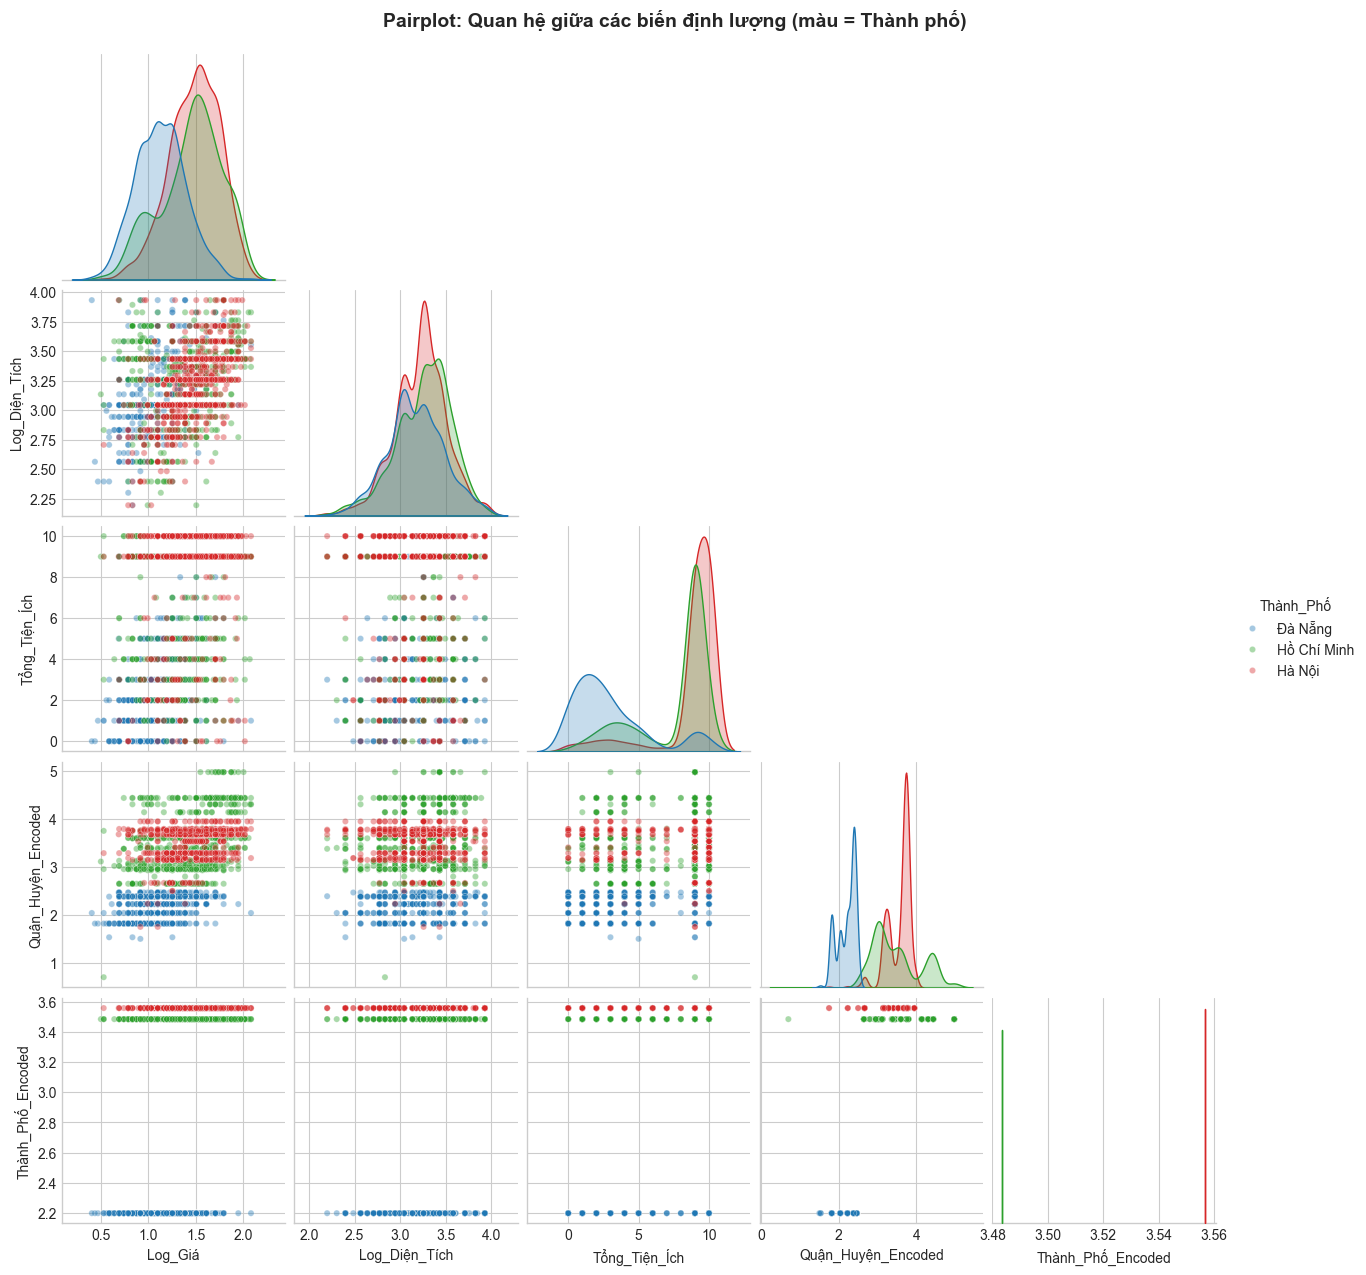

In [20]:
pair_cols = ['Log_Giá', 'Log_Diện_Tích', 'Tổng_Tiện_Ích',
             'Quận_Huyện_Encoded', 'Thành_Phố_Encoded']

g = sns.pairplot(df_clean[pair_cols + ['Thành_Phố']],
                 hue='Thành_Phố', palette=PALETTE,
                 plot_kws={'alpha': 0.4, 's': 20},
                 diag_kind='kde', corner=True)
g.fig.suptitle('Pairplot: Quan hệ giữa các biến định lượng (màu = Thành phố)',
               fontsize=14, fontweight='bold', y=1.02)
plt.show()


### 7.2 lmplot — Hồi quy Diện tích → Giá, phân hóa theo Thành phố

> **Câu hỏi:** Mối quan hệ giữa diện tích và giá có *đồng nhất* giữa 3 thành phố không, hay mỗi thành phố có *hệ số góc riêng* (intercept và slope khác nhau)?

`lmplot` vẽ đường hồi quy riêng cho từng nhóm (Thành phố), giúp phát hiện *interaction effect* giữa vị trí địa lý và diện tích.


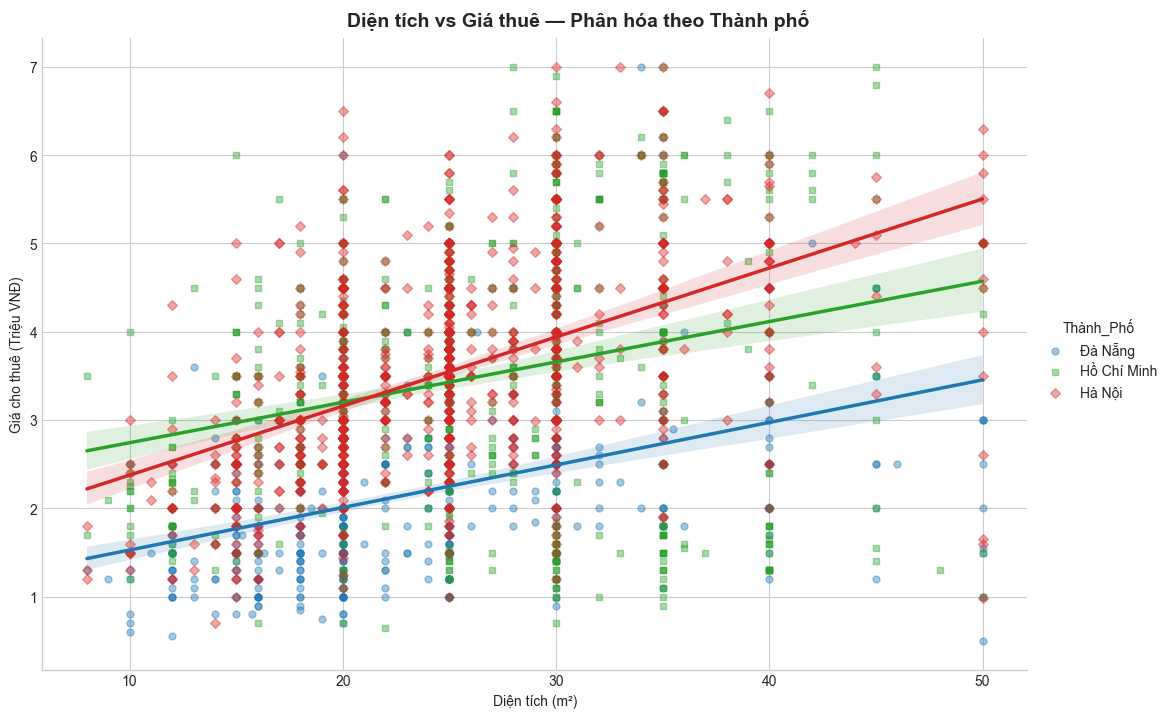

In [21]:
g = sns.lmplot(data=df_clean,
               x='Diện_Tích_m2', y='Giá_Cho_Thuê',
               hue='Thành_Phố', palette=PALETTE,
               height=7, aspect=1.5,
               markers=['o', 's', 'D'],
               scatter_kws={'alpha': 0.4, 's': 25},
               line_kws={'linewidth': 2.5})
g.fig.suptitle('Diện tích vs Giá thuê — Phân hóa theo Thành phố',
               fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels('Diện tích (m²)', 'Giá cho thuê (Triệu VNĐ)')
plt.show()


### 7.3 Grouped bar — Tỉ lệ sở hữu tiện ích theo từng thành phố

> **Câu hỏi:** "Hệ sinh thái tiện ích" có khác nhau giữa Đà Nẵng, Hà Nội và TP.HCM không? Nếu có, sự khác biệt này có giải thích một phần chênh lệch giá giữa các thành phố không?

Biểu đồ grouped bar cho thấy % phòng *có* từng loại tiện ích, phân nhóm theo thành phố — phát hiện *đặc trưng cấu trúc thị trường* của từng vùng.


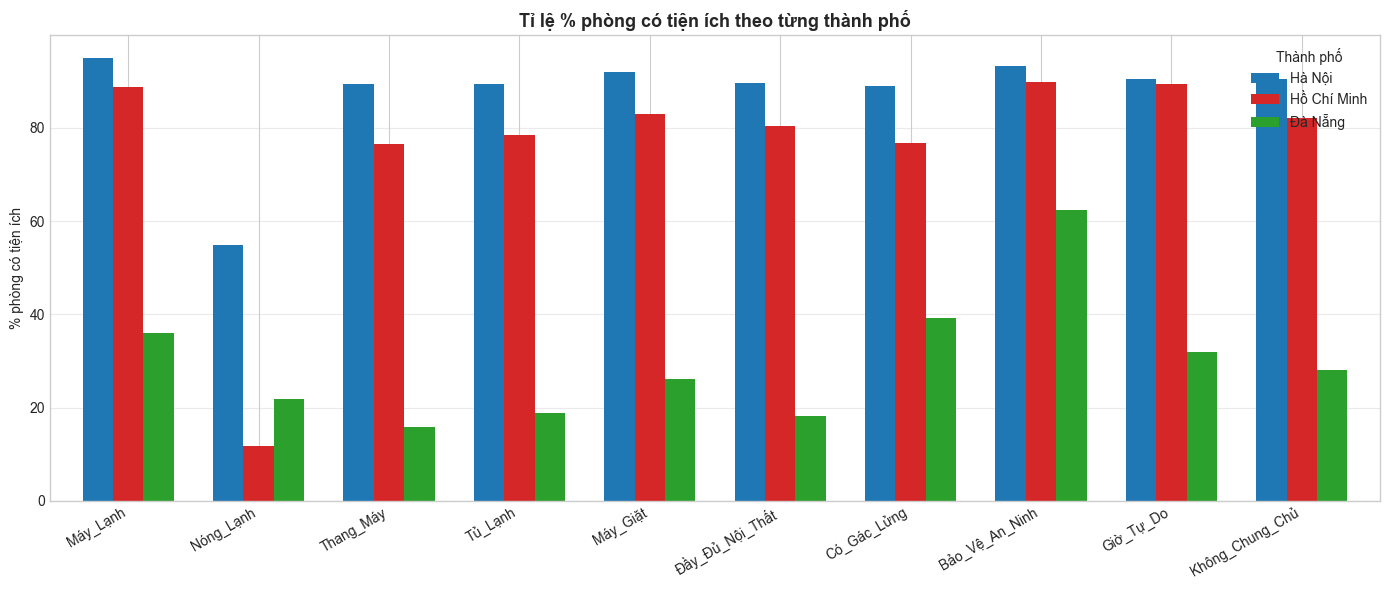

In [22]:
# Tỉ lệ % phòng có tiện ích, phân theo thành phố
utility_by_city = df_clean.groupby('Thành_Phố')[UTILITY_COLS].mean() * 100

fig, ax = plt.subplots(figsize=(14, 6))
utility_by_city.T.plot(kind='bar', ax=ax, color=list(PALETTE.values()), width=0.7)
ax.set_title('Tỉ lệ % phòng có tiện ích theo từng thành phố', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% phòng có tiện ích')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Thành phố')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


### 7.4 Regplot — Tổng số tiện ích → Giá cho thuê

> **Kiểm chứng giả thuyết:** *Phòng có nhiều tiện ích hơn → giá cao hơn* — điều này nghe có vẻ hiển nhiên, nhưng tương quan thực tế mạnh đến đâu? Có đơn điệu (monotonic) không hay có ngưỡng bão hòa?

`regplot` vẽ đám mây điểm + đường hồi quy + vùng tin cậy 95%, giúp đánh giá trực quan *strength* và *linearity* của mối quan hệ này.


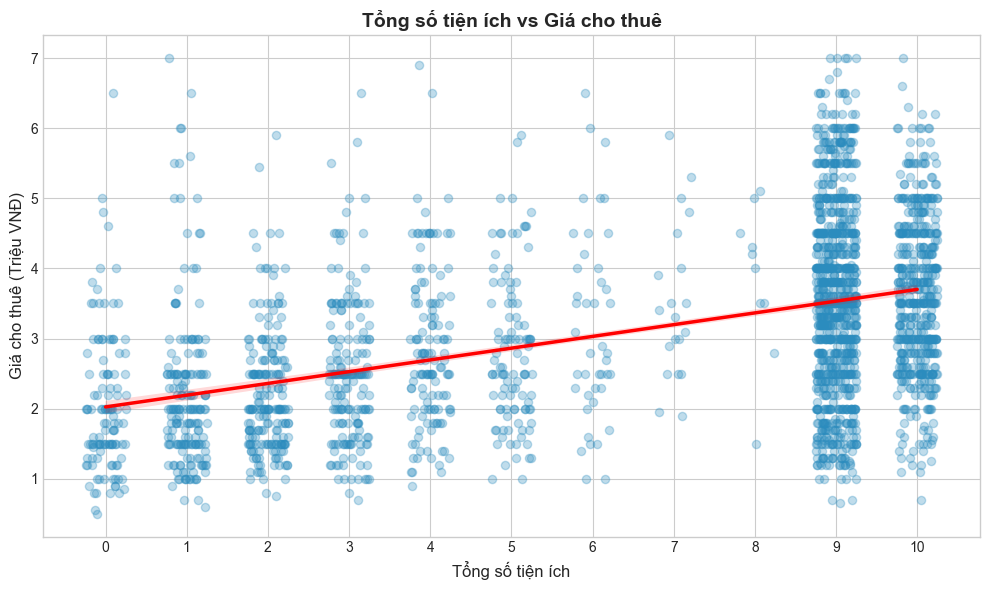

In [23]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df_clean, x='Tổng_Tiện_Ích', y='Giá_Cho_Thuê',
            scatter_kws={'alpha': 0.3, 'color': '#2b8cbe', 's': 35},
            line_kws={'color': 'red', 'linewidth': 2.5},
            x_jitter=0.25)
plt.title('Tổng số tiện ích vs Giá cho thuê', fontsize=14, fontweight='bold')
plt.xlabel('Tổng số tiện ích', fontsize=12)
plt.ylabel('Giá cho thuê (Triệu VNĐ)', fontsize=12)
plt.xticks(range(0, 11))
plt.tight_layout()
plt.show()


### 7.5 KDE plot & Boxplot — Phân bố giá theo thành phố

> Hai biểu đồ bổ trợ cho nhau:
> - **KDE plot** (trái): Hình dạng *toàn bộ phân phối* — phân phối có một đỉnh hay nhiều đỉnh? Có chồng lấn giữa thành phố không?
> - **Boxplot** (phải): Trung vị, IQR và outlier — so sánh *vị trí trung tâm* và *mức độ phân tán* giá giữa các thành phố.


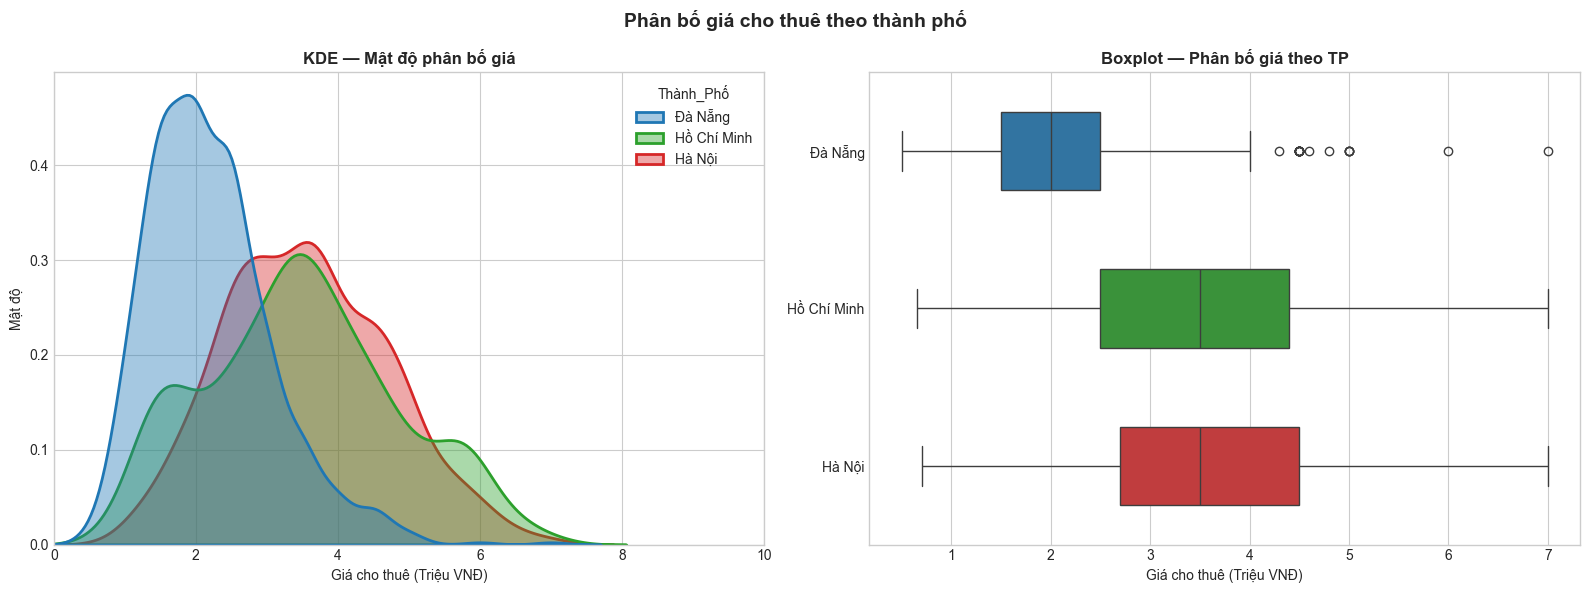

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phân bố giá cho thuê theo thành phố', fontsize=14, fontweight='bold')

# KDE
for city, color in PALETTE.items():
    subset = df_clean[df_clean['Thành_Phố'] == city]['Giá_Cho_Thuê']
    axes[0].fill_between(sorted(subset), 0, color=color, alpha=0.2)
sns.kdeplot(data=df_clean, x='Giá_Cho_Thuê', hue='Thành_Phố',
            fill=True, common_norm=False, palette=PALETTE,
            alpha=0.4, linewidth=2, ax=axes[0])
axes[0].set_title('KDE — Mật độ phân bố giá', fontweight='bold')
axes[0].set_xlabel('Giá cho thuê (Triệu VNĐ)')
axes[0].set_ylabel('Mật độ')
axes[0].set_xlim(0, 10)

# Boxplot ngang
sns.boxplot(data=df_clean, x='Giá_Cho_Thuê', y='Thành_Phố',
            palette=PALETTE, width=0.5, ax=axes[1])
axes[1].set_title('Boxplot — Phân bố giá theo TP', fontweight='bold')
axes[1].set_xlabel('Giá cho thuê (Triệu VNĐ)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


### 7.6 So sánh giá trung bình khi có / không có từng tiện ích

> **Câu hỏi then chốt:** Mỗi tiện ích *thực sự* làm tăng giá bao nhiêu triệu? Tiện ích nào là "game changer" và tiện ích nào chỉ là "đương nhiên có"?

Biểu đồ grouped bar so sánh giá trung bình của nhóm phòng *có* và *không có* từng tiện ích — delta giữa hai cột chính là *premium* mà tiện ích đó tạo ra.


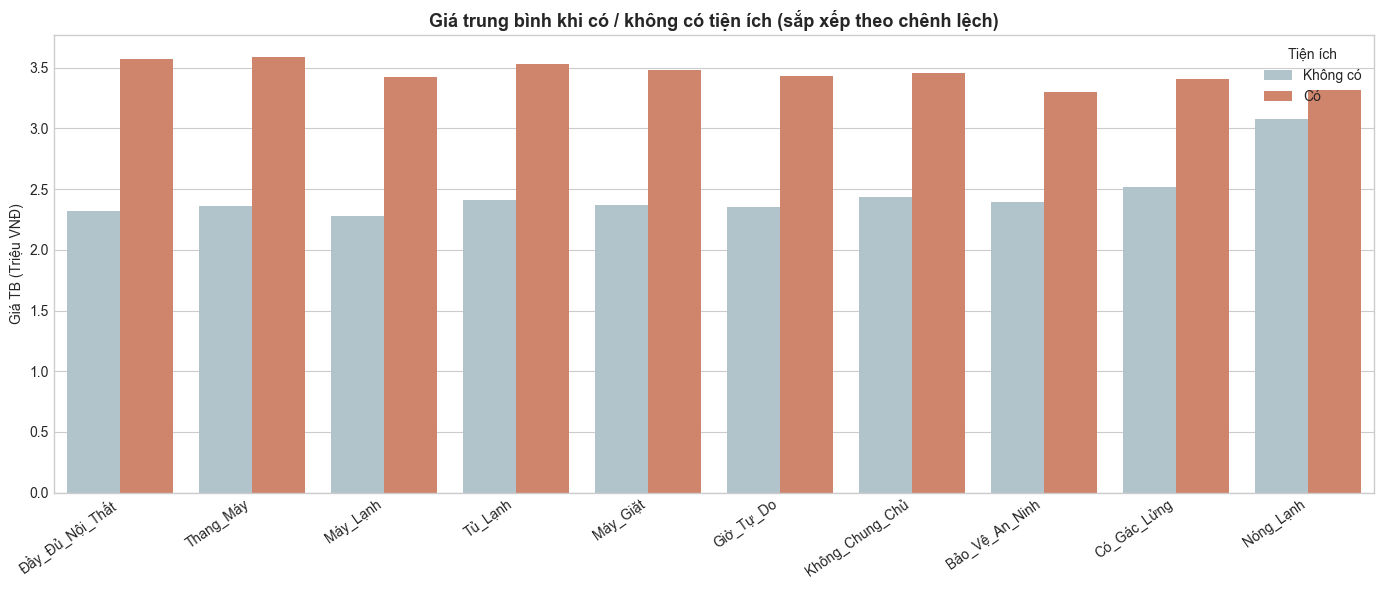


Chênh lệch giá (Có - Không có tiện ích):


Tiện_Ích
Đầy_Đủ_Nội_Thất    1.25
Thang_Máy          1.23
Máy_Lạnh           1.14
Tủ_Lạnh            1.13
Máy_Giặt           1.11
Giờ_Tự_Do          1.08
Không_Chung_Chủ    1.02
Bảo_Vệ_An_Ninh     0.91
Có_Gác_Lửng        0.90
Nóng_Lạnh          0.24
Name: Chênh lệch, dtype: float64

In [25]:
rows = []
for col in UTILITY_COLS:
    rows.append({'Tiện_Ích': col, 'Trạng_Thái': 'Không có',
                 'Giá_TB': df_clean[df_clean[col]==0]['Giá_Cho_Thuê'].mean()})
    rows.append({'Tiện_Ích': col, 'Trạng_Thái': 'Có',
                 'Giá_TB': df_clean[df_clean[col]==1]['Giá_Cho_Thuê'].mean()})

df_util = pd.DataFrame(rows)

# Sắp xếp theo chênh lệch giá
diff = df_util.pivot(index='Tiện_Ích', columns='Trạng_Thái', values='Giá_TB')
diff['Chênh lệch'] = diff['Có'] - diff['Không có']
order = diff['Chênh lệch'].sort_values(ascending=False).index

plt.figure(figsize=(14, 6))
sns.barplot(data=df_util, x='Tiện_Ích', y='Giá_TB',
            hue='Trạng_Thái', palette=['#aec6cf', '#e07b5b'], order=order)
plt.title('Giá trung bình khi có / không có tiện ích (sắp xếp theo chênh lệch)',
          fontsize=13, fontweight='bold')
plt.xlabel('')
plt.ylabel('Giá TB (Triệu VNĐ)')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Tiện ích')
plt.tight_layout()
plt.show()

print("\nChênh lệch giá (Có - Không có tiện ích):")
display(diff['Chênh lệch'].sort_values(ascending=False).round(2))


### 7.7 Xếp hạng giá trung bình theo Quận/Huyện

> **Biến `Quận_Huyện`** có tương quan cao nhất với giá trong heatmap (mục 6). Biểu đồ này cụ thể hóa: *quận nào đắt nhất, rẻ nhất* trong từng thành phố?

Horizontal bar chart phân nhóm theo thành phố, sắp xếp từ cao xuống thấp — trực tiếp giải thích tại sao Target Encoding theo giá trung bình là encoding *có ý nghĩa* cho biến vị trí này.


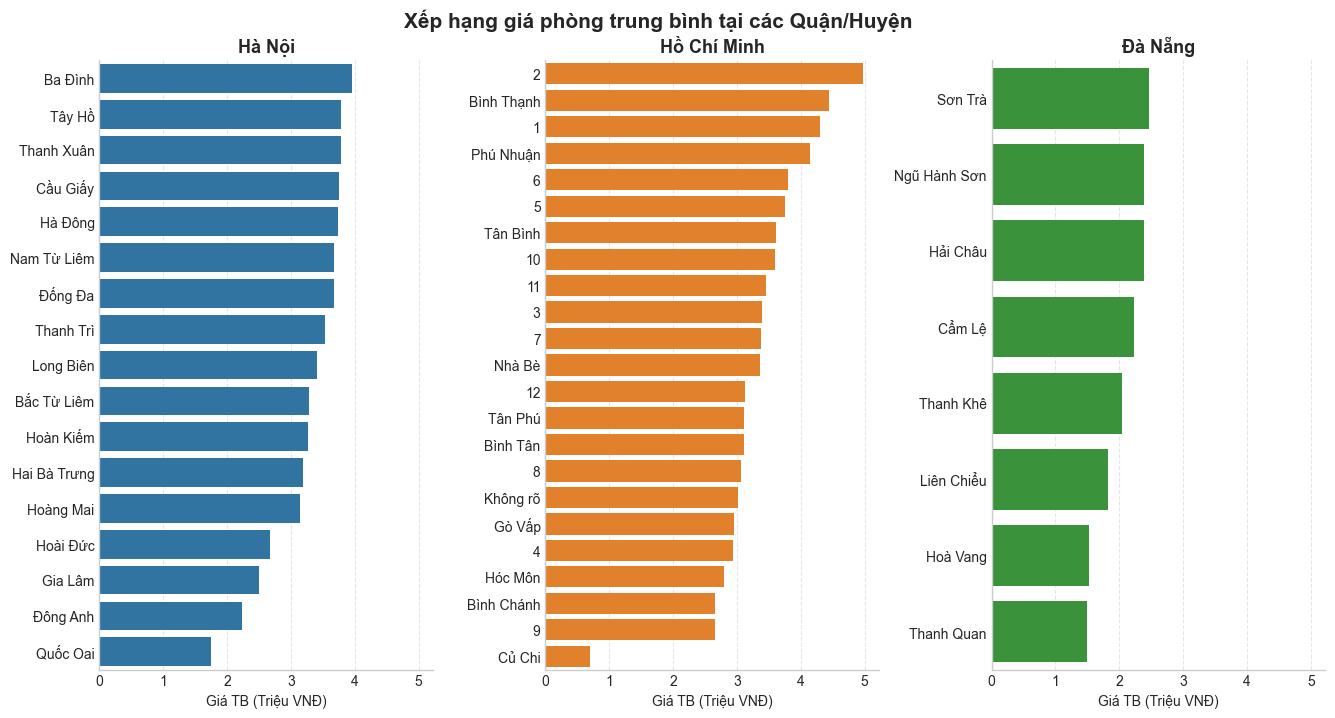

In [26]:
district_avg = (df_clean.groupby(['Thành_Phố', 'Quận_Huyện'])['Giá_Cho_Thuê']
                   .mean().reset_index()
                   .sort_values(['Thành_Phố', 'Giá_Cho_Thuê'], ascending=[True, False]))

g = sns.catplot(data=district_avg, x='Giá_Cho_Thuê', y='Quận_Huyện',
                col='Thành_Phố', kind='bar',
                height=7, aspect=0.65, sharey=False,
                hue='Thành_Phố', dodge=False, legend=False)
g.fig.suptitle('Xếp hạng giá phòng trung bình tại các Quận/Huyện',
               fontsize=15, fontweight='bold', y=1.02)
g.set_axis_labels('Giá TB (Triệu VNĐ)', '')
g.set_titles('{col_name}', size=13, fontweight='bold')
for ax in g.axes.flat:
    ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


### 7.8 t-SNE — Kiểm tra cấu trúc cụm trong không gian 12 chiều

**t-SNE** (t-distributed Stochastic Neighbor Embedding) là kỹ thuật giảm chiều phi tuyến, chiếu dữ liệu từ không gian nhiều chiều xuống 2D để *mắt người có thể quan sát được*.

> **Thiết kế thử nghiệm quan trọng:** t-SNE chỉ được cung cấp **Tiện ích + Diện tích** (12 features) — *hoàn toàn không biết giá*. Sau khi chiếu xuống 2D, ta tô màu các điểm theo:
> 1. **Thành phố** → kiểm tra xem 3 thành phố có tách biệt về hồ sơ tiện ích không.
> 2. **Mức giá** → nếu điểm màu đỏ (đắt) và xanh (rẻ) tự động tách ra mà t-SNE không biết giá → **tiện ích + diện tích đủ để phân biệt phân khúc giá**.

Đây là bằng chứng gián tiếp mạnh nhất rằng tập features đã chọn *thực sự có tính dự báo*.


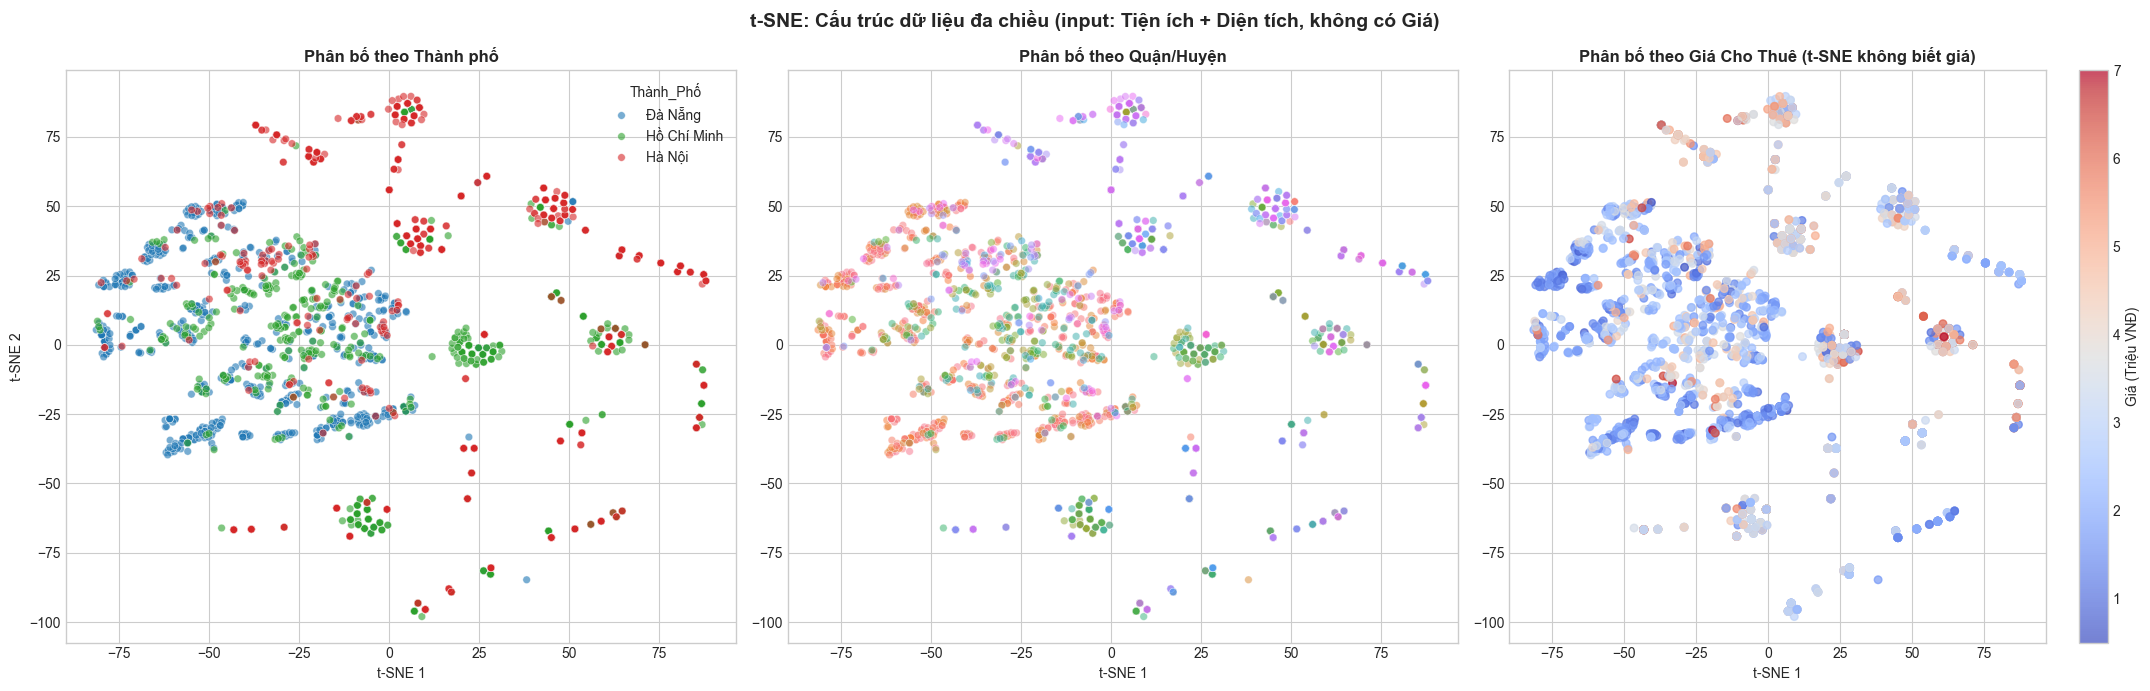

In [27]:
TSNE_FEATURES = ['Log_Diện_Tích', 'Tổng_Tiện_Ích'] + UTILITY_COLS

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[TSNE_FEATURES])

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, n_jobs=-1)
tsne_result = tsne.fit_transform(X_scaled)

df_clean['tsne_x'] = tsne_result[:, 0]
df_clean['tsne_y'] = tsne_result[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('t-SNE: Cấu trúc dữ liệu đa chiều (input: Tiện ích + Diện tích, không có Giá)',
             fontsize=14, fontweight='bold')

# Góc nhìn 1: Thành phố
sns.scatterplot(ax=axes[0], x='tsne_x', y='tsne_y', hue='Thành_Phố',
                palette=PALETTE, data=df_clean, alpha=0.6, s=30)
axes[0].set_title('Phân bố theo Thành phố', fontweight='bold')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')

# Góc nhìn 2: Quận/Huyện (legend tắt để tránh rối)
sns.scatterplot(ax=axes[1], x='tsne_x', y='tsne_y', hue='Quận_Huyện',
                palette='husl', data=df_clean, alpha=0.5, s=30, legend=False)
axes[1].set_title('Phân bố theo Quận/Huyện', fontweight='bold')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('')

# Góc nhìn 3: Màu gradient theo Giá
sc = axes[2].scatter(df_clean['tsne_x'], df_clean['tsne_y'],
                     c=df_clean['Giá_Cho_Thuê'], cmap='coolwarm', alpha=0.7, s=30)
axes[2].set_title('Phân bố theo Giá Cho Thuê (t-SNE không biết giá)',
                  fontweight='bold')
axes[2].set_xlabel('t-SNE 1'); axes[2].set_ylabel('')
plt.colorbar(sc, ax=axes[2], label='Giá (Triệu VNĐ)')

plt.tight_layout()
plt.show()

df_clean.drop(columns=['tsne_x', 'tsne_y'], inplace=True)


**Nhận xét t-SNE:**
1. **Đà Nẵng** tách biệt hoàn toàn → hồ sơ tiện ích và diện tích khác biệt so với 2 siêu đô thị.
2. **Hà Nội & TP.HCM** chồng lấn → cấu trúc thị trường tương đồng.
3. Khi tô màu theo **Giá** (mà t-SNE không biết): vùng đỏ (giá cao) tự động tách khỏi vùng xanh (giá thấp) → xác nhận rằng Tiện ích + Diện tích mang đủ thông tin phân biệt phân khúc giá.


---
## 8. Đánh giá tầm quan trọng đặc trưng (Feature Importance)

> **Tại sao cần Random Forest sau khi đã có Pearson correlation?**
>
> Pearson chỉ đo *tương quan tuyến tính từng cặp* — bỏ qua:
> - Quan hệ phi tuyến (non-linear effects).
> - Tương tác giữa các features (interaction effects).
> - Ảnh hưởng khi các features cùng có mặt (joint contribution).
>
> Random Forest đo *mức đóng góp thực tế* của từng feature khi *tất cả features cùng được dùng* — một đánh giá toàn diện và thực tiễn hơn.

**Metric:** Feature importance = % giảm trung bình của MSE trên tập OOB (Out-of-Bag) khi feature đó bị "shuffle" ngẫu nhiên.


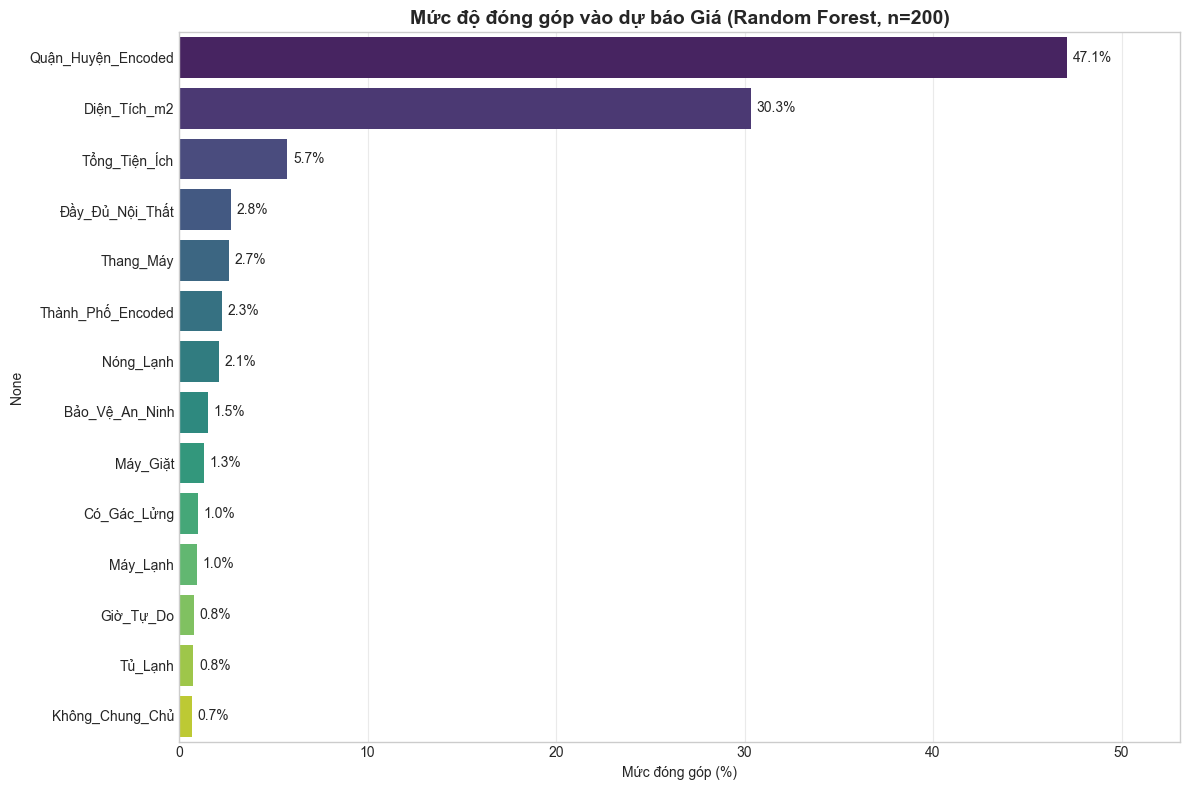


Top 5 feature quan trọng nhất:
  Quận_Huyện_Encoded       : 47.1%
  Diện_Tích_m2             : 30.3%
  Tổng_Tiện_Ích            : 5.7%
  Đầy_Đủ_Nội_Thất          : 2.8%
  Thang_Máy                : 2.7%


In [28]:
DROP_COLS = ['Thành_Phố', 'Quận_Huyện', 'Giá_Cho_Thuê', 'Log_Giá', 'Log_Diện_Tích']
X = df_clean.drop(columns=DROP_COLS)
y = df_clean['Giá_Cho_Thuê']

rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_ * 100, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
bars = sns.barplot(x=importances.values, y=importances.index, palette='viridis', ax=ax)
ax.set_title('Mức độ đóng góp vào dự báo Giá (Random Forest, n=200)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mức đóng góp (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=10, xytext=(4, 0),
                textcoords='offset points')
ax.set_xlim(0, importances.max() + 6)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

print("\nTop 5 feature quan trọng nhất:")
for feat, imp in importances.head(5).items():
    print(f"  {feat:<25}: {imp:.1f}%")


> **📊 Nhận xét Feature Importance (Random Forest):**
>
> Kết quả xác nhận và bổ sung cho phân tích tương quan Pearson trước đó:
> 1. **`Quận_Huyện_Encoded`** (~47%) — vị trí địa lý cấp quận là yếu tố *quyết định* giá. Hai phòng giống hệt nhau nhưng khác quận có thể chênh nhau gần 2 triệu.
> 2. **`Diện_Tích_m2`** (~30%) — sau vị trí, diện tích là yếu tố vật lý quan trọng nhất.
> 3. **Nhóm tiện ích cao cấp** (`Thang_Máy`, `Đầy_Đủ_Nội_Thất`, `Tủ_Lạnh`) — cộng gộp ~15–20%.
> 4. **`Nóng_Lạnh`** gần như không đóng góp (~1%) — xác nhận lại kết quả tương quan Pearson thấp.
>
> → **Kết luận thực tiễn:** Để dự đoán giá phòng trọ tốt, *ba thông tin quan trọng nhất cần có* là: Quận/Huyện, Diện tích, và Có thang máy/full nội thất hay không.


## 9. Kết luận
Qua quá trình phân tích dữ liệu toàn diện, có thể khẳng định bài toán dự đoán giá phòng trọ **hoàn toàn khả thi về mặt dữ liệu**. Các kết quả chính:

**1. Đặc trưng quyết định giá (theo thứ tự quan trọng):**
- **Vị trí địa lý (Quận/Huyện):** ~47% đóng góp theo Random Forest. Quận trung tâm = giá cao hơn hẳn.
- **Diện tích:** ~30% — yếu tố vật lý cốt lõi sau khi vị trí đã cố định.
- **Hệ sinh thái tiện ích:** ~20% tổng cộng — Thang máy, Full nội thất, Tủ lạnh có tác động mạnh nhất.

**2. Phát hiện quan trọng từ phân tích:**
- Clustermap xác nhận hai nhóm tiện ích rõ ràng: nhóm "cao cấp" (Thang máy + Nội thất + Tủ lạnh + Máy giặt) và nhóm "cơ bản" (Máy lạnh + Nóng lạnh).
- t-SNE không được cung cấp thông tin giá nhưng tự động phân tách được phòng giá cao / giá thấp → dữ liệu có cấu trúc cụm tốt, mô hình ML sẽ hiệu quả.
- `Nóng_Lạnh` có tương quan gần 0 → đã trở thành tiêu chuẩn mặc định, không còn phân hóa giá.

**3. Đề xuất cho bước Modeling tiếp theo:**
- Sử dụng `Log_Giá` làm biến mục tiêu (phân phối chuẩn hơn).
- Ưu tiên các mô hình có thể xử lý quan hệ phi tuyến: Random Forest, XGBoost, hoặc Ridge Regression với feature interactions.
- Thực hiện cross-validation theo thành phố để tránh data leakage địa lý.


## 10. Tài liệu tham khảo
- Phạm Đình Khánh (2019). *Kỹ thuật Feature Engineering*. https://phamdinhkhanh.github.io/2019/01/07/Ky_thuat_feature_engineering.html
- DataCamp (2023). *Introduction to t-SNE*. https://www.datacamp.com/tutorial/introduction-t-sne
- DataCamp (2023). *Random Forests Classifier*. https://www.datacamp.com/tutorial/random-forests-classifier-python
- Seaborn documentation. *seaborn.clustermap*. https://seaborn.pydata.org/generated/seaborn.clustermap.html
- Scikit-learn documentation. *RandomForestRegressor*. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
